In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Array attributes

### 1

In [381]:
# 1. Создайте массив длины 10, заполненный нулями
# 2. Сделайте полученный массив неизменяемым
x = np.zeros(10)
x

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [388]:
x = np.arange(4).reshape(2, 2)
x

array([[0, 1],
       [2, 3]])

In [389]:
x.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [391]:
y = x.T
y.flags

  C_CONTIGUOUS : False
  F_CONTIGUOUS : True
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [395]:
z = x.reshape(4, 1)
z.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [398]:
%%time
x = np.ones((5000, 5000))

CPU times: user 17.6 ms, sys: 54.4 ms, total: 72 ms
Wall time: 69.5 ms


In [399]:
%%time
y = x.T

CPU times: user 8 µs, sys: 8 µs, total: 16 µs
Wall time: 25.3 µs


In [171]:
x.flags.writeable = False
x[0] = 1

ValueError: assignment destination is read-only

## Constructing arrays

### 2

In [400]:
# 1. Создайте массив, содержащий 5 равноотстоящих точек, покрывающих диапазон от 0 до 2*pi
# 2. Создайте массив, содержащий 5 равноотстоящих в логарифмическом масштабе точек, покрывающих диапазон от 10 до 100
# 3. Составьте из полученных массивов координатную сеть (meshgrid) 
x = np.linspace(0, 2*np.pi, 5)
y = np.logspace(1, 2, 5)
xx, yy = np.meshgrid(x, y)

In [401]:
xx, yy

(array([[0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531],
        [0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531],
        [0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531],
        [0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531],
        [0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531]]),
 array([[ 10.        ,  10.        ,  10.        ,  10.        ,
          10.        ],
        [ 17.7827941 ,  17.7827941 ,  17.7827941 ,  17.7827941 ,
          17.7827941 ],
        [ 31.6227766 ,  31.6227766 ,  31.6227766 ,  31.6227766 ,
          31.6227766 ],
        [ 56.23413252,  56.23413252,  56.23413252,  56.23413252,
          56.23413252],
        [100.        , 100.        , 100.        , 100.        ,
         100.        ]]))

In [402]:
xx.strides

(40, 8)

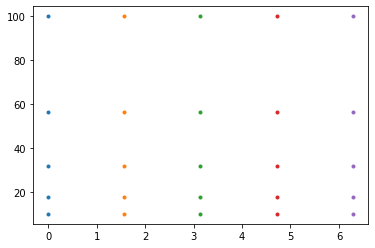

In [312]:
plt.plot(xx, yy, marker='.', linestyle='none')
plt.show()

In [403]:
def func(x, y):
    return 2 * x + y + 8

In [407]:
x = np.linspace(0, 2*np.pi, 5)
y = np.logspace(1, 2, 5)
x, y

(array([0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531]),
 array([ 10.        ,  17.7827941 ,  31.6227766 ,  56.23413252,
        100.        ]))

In [408]:
func(xx, yy)

array([[ 18.        ,  21.14159265,  24.28318531,  27.42477796,
         30.56637061],
       [ 25.7827941 ,  28.92438675,  32.06597941,  35.20757206,
         38.34916471],
       [ 39.6227766 ,  42.76436926,  45.90596191,  49.04755456,
         52.18914722],
       [ 64.23413252,  67.37572517,  70.51731783,  73.65891048,
         76.80050313],
       [108.        , 111.14159265, 114.28318531, 117.42477796,
        120.56637061]])

### 3

In [87]:
# Создайте двумерный массив 5х5 с элементами 1, 2, 3 и 4 под главной диагональю, остальные элементы заполните нулями

In [95]:
x = np.array([1, 2, 3, 4])
x = np.diag(x, k=-1)
x

array([[0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 2, 0, 0, 0],
       [0, 0, 3, 0, 0],
       [0, 0, 0, 4, 0]])

### 4

In [97]:
# 1. Создайте функцию-генератор, последовательно возвращающую целые числа от 0 до 9
# 2. Создайте массив из построенного генератора"

In [313]:
def gen():
    for i in range(9):
        yield i

In [455]:
x = np.fromiter(gen(), dtype=int, count=-1)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [447]:
it = [1, 2, 3]

In [450]:
iterator = iter(it)
while True:
    try:
        print(next(iterator))
    except StopIteration:
        break

1
2
3


In [451]:
iter(iterator)

In [453]:
iterator

### 5

In [150]:
# "Что будет выведено на экран?
# a = np.arange(4).reshape(2,2)
# a += 0.5
# print(a)"

# Error: since we canot put a float to integer array 
# But if we do the following:
# a = np.arange(4).reshape(2,2)
# a = a + 0.5
# print(a)"
# It works!

In [460]:
a = np.arange(10000000)

In [466]:
%%time
c = np.empty_like(a)
c

CPU times: user 147 µs, sys: 0 ns, total: 147 µs
Wall time: 159 µs


array([0, 0, 0, ..., 0, 0, 0])

In [458]:
%%time
a += 1

CPU times: user 10.5 ms, sys: 552 µs, total: 11.1 ms
Wall time: 8.83 ms


In [461]:
print(a)

[      0       1       2 ... 9999997 9999998 9999999]


In [462]:
%%time
b = a + 1

CPU times: user 19.1 ms, sys: 19.9 ms, total: 39 ms
Wall time: 36.5 ms


In [467]:
%%time
c = a.copy()

CPU times: user 35.3 ms, sys: 19.9 ms, total: 55.3 ms
Wall time: 47.9 ms


In [464]:
id(a), id(b)

(140310470271024, 140310470299888)

### 6

In [169]:
#"Что будет выведено на экран?"
# a = np.array([1]) 
# if a:
#     print(True)
# else:
#     print(False)

# a = np.array([1, 2, 3])
# if a:
#     print(True)
# else:
#     print(False)


# Array contains only one element which is not None -> True
# Since array contains several elements, we cannot do comparison of the whole array -> Error

In [470]:
a = []
if a:
    print(True)

### 7

In [180]:
# "Что будет выведено на экран?
# print(0 * np.nan) 
# print(np.nan - np.nan)
# print(np.nan == np.nan)
# print(np.nan is np.nan)
# print(-np.inf < np.nan < np.inf)


# value * np.nan = np.nan always -> nan
# Any arithmetic operation with nan is nan -> nan
# False, cause we don't want to get np.nan - np.nan = 0 
# True
# nan is not a number -> False

### 8

In [220]:
# "Что будет выведено на экран?"
# print(np.isnan(np.array([np.nan]).astype(np.int)))

# False, since np.nan is a floating point value 

In [216]:
np.array([np.nan]).astype(int)

array([-9223372036854775808])

In [213]:
np.array([np.inf]).astype(int)

array([-9223372036854775808])

In [218]:
np.array([np.nan]).astype(float)

array([nan])

In [476]:
np.int8(-1).view(np.uint8)

255

In [484]:
np.float32(10000000000000000000) + 1

9.999999980506448e+18

In [487]:
np.int32(245653).tobytes()

b'\x95\xbf\x03\x00'

In [488]:
np.int32(245653).view(np.float32)

3.44233e-40

In [496]:
np.int32(16777217).astype(np.float32)

16777216.0

### 9

In [225]:
# "1. Создайте масив из четырех элементов: 0, 10, 20, 30
# 2. Создайте двухмерный массив 4x5, в котором первый столбец - массив с шага 1, а каждый элемент каждой строки, начиная со второго,  больше предыдущего элемента этой же строки на 1."

In [284]:
x = np.array([0, 10, 20, 30]) # shape 4 

In [289]:
x = x.reshape(-1, 1) # shape 4 x 1
y = np.arange(5) # shape 5
z = x + y # shape 4 x 5
z

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34]])

In [ ]:
np.reshape()

### 10

In [296]:
# Какой shape будет у результата операции np.arange(5).reshape(1,-1) + np.arange(5).reshape(-1,1)?
# np.arange(5).reshape(1,-1) --- shape 1 x 5 
# np.arange(5).reshape(-1,1) --- shape 5 x 1
# following the broadcasting rules -> shape 5 x 5

In [295]:
np.arange(5).reshape(1, -1) + np.arange(5).reshape(-1, 1)

array([[0, 1, 2, 3, 4],
       [1, 2, 3, 4, 5],
       [2, 3, 4, 5, 6],
       [3, 4, 5, 6, 7],
       [4, 5, 6, 7, 8]])

### 11

In [876]:
x = np.zeros((8, 8))
x[::2, ::2] = 1
x[1::2, 1::2] = 1
x

array([[1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 1.],
       [1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 1.],
       [1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 1.],
       [1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 1.]])

### 12

In [379]:
x = np.arange(1, 6)
y = np.zeros(9)
y[::2] = x
y

array([1., 0., 2., 0., 3., 0., 4., 0., 5.])

### 13

In [586]:
# "Что будет выведено на экран?"
# x = np.arange(36).reshape(2, 3, 2, 3)
# print(x[..., 0, ...])


# Error since it is unclear what indiced are omitted

### 14

In [608]:
# "Что будет выведено на экран?"
# x = np.arange(16).reshape(4,4)
# # y = x[:, [2,3]]
# # y[:] = 0
# # print(x)
# # y = x[:,:2]
# # y[:] = 0
# # print(x)

# Advanced indexing returns a copy of an array, while basic indexing returns a view -> in the second case we obtain x with 0 in the first two columns

In [54]:
a = np.arange(1, 5).reshape(2, 2)
id(a)

140621599545552

In [58]:
id(a[[0, 0]])

140621599546416

In [62]:
id(a[(0, 0),])

140621599546896

In [68]:
b = a[(0, 0)]

In [60]:
id(a[[0, 0], :])

140621599547088

In [37]:
a.strides

(16, 8)

In [74]:
b = a[(1, slice(None))]
b

array([3, 4])

In [38]:
b.strides

(8,)

In [34]:
b[0] = 5

In [46]:
a = np.array([1, 2, 3, 4, 5])
b = a[[0, 1, 3]]

In [48]:
b[0] = 10

In [49]:
a

array([1, 2, 3, 4, 5])

In [ ]:
def mygetitem(arr, key):
    if int/slice:
        non-advanced
    if isinstance(key, tuple):
        
    if isiterable(key):

In [905]:
b = a[[1, slice(None)]]
b

/tmp/ipykernel_10114/1040244417.py:1: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  b = a[[1, slice(None)]]


array([3, 4])

In [903]:
b = a[[1, [0, 1]]]
b

/tmp/ipykernel_10114/2661637347.py:1: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  b = a[[1, [0, 1]]]


array([3, 4])

In [906]:
b[0] = 18
a

array([[ 1,  2],
       [18,  4]])

In [898]:
c = a[(1, [0, 1])]
c

array([0, 4])

In [899]:
a

array([[1, 2],
       [0, 4]])

In [900]:
c[1] = 10

In [901]:
a

array([[1, 2],
       [0, 4]])

In [895]:
a[[1, 1]]

array([[0, 4],
       [0, 4]])

In [909]:
a = np.arange(15).reshape(3, 5)
a[[0, 2]] = 1
a

array([[1, 1, 1, 1, 1],
       [5, 6, 7, 8, 9],
       [1, 1, 1, 1, 1]])

In [ ]:
a = np.arange(15).reshape(3, 5)
b = a[[0, 2]]
b[:] = 1
print(a)
print(b)

In [894]:
a[1]

array([0, 4])

In [892]:
a[1, slice(None)]

array([0, 4])

In [875]:
x[::2, ::2] = 1
x

array([[1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [891]:
a[1, slice(None)]

array([0, 4])

In [888]:
b

array([3, 4])

In [889]:
b[0] = 0

In [890]:
a

array([[1, 2],
       [0, 4]])

In [886]:
a[1, :]

array([3, 4])

### 15

In [614]:
# Замените отрицательные элементы массива нулем.

x = np.arange(-10, 10)
x[x < 0 ] = 0
x

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [619]:
x = np.arange(-10, 10).reshape(4, 5)
x[x < 0] = 0
x

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

### 16

In [929]:
# "На примере целочисленного массива x = np.array([[1,2,3], [1,1,1], [2,2,1], [2,2,2]], dtype=int)
# составьте новый массив, не содержащий строки, полностью заполненные одним уникальным значением
#"

x = np.array([[1, 2, 3], [1, 1, 1], [2, 2, 1], [2, 2, 2], [2, 3, 1]], dtype=int)
y = np.any(x - x[:, 0, np.newaxis], axis=1)
x[y]

array([[1, 2, 3],
       [2, 2, 1],
       [2, 3, 1]])

In [934]:
x = np.array([[1, 2, 3], [1, 1, 1], [2, 2, 1], [2, 2, 2], [2, 3, 1]], dtype=int)
y = np.max(x, axis=1) != np.min(x, axis=1)
x[y]

array([[1, 2, 3],
       [2, 2, 1],
       [2, 3, 1]])

### 17

In [776]:
# Для заданного одномерного массива x выведите все элементы, не превышающие своих соседей 
# (первый и последний элемент сравниваются только со вторым и предпоследним соответственно)

In [778]:
# first version
x = np.random.choice(100, 100)
result = x[1:-1][(x[1:-1] <= np.roll(x, 1)[1:-1]) & (x[1:-1] <= np.roll(x, -1)[1:-1])]
if x[0] <= x[1]:
    result = np.insert(result, 0, x[0])
if x[-1] <= x[-2]:
    result = np.append(result, x[-1])
print(x)
result

[70 37  2 14  6  1 82 52 28 74 26  3 92 82 60 59 14 68 94 29 89 70 65 16
 69 62 18 49 85 90 71 73 95 88 19  4 10 90 81 78 74  1 62  1 43 72 80 35
  5 42 75 94 58 68 55  8 23 42 64 73 58 27  5 34 93 32 26 93 67 91 84 30
 32 94 21 82 68 13 10 14 29 79 66 16 99 77 19 24 22 10 16 33 65 86 32 80
 97 75 24 98]


array([ 2,  1, 28,  3, 14, 29, 16, 18, 71,  4,  1,  1,  5, 58,  8,  5, 26,
       67, 30, 21, 10, 16, 19, 10, 32, 24])

In [148]:
# second version
x = np.random.choice(10, 10)

In [149]:
mask = np.ones(x.shape, dtype=bool)
mask[1:] = x[1:] <= x[:-1]
mask[:-1] = mask[:-1] & (x[:-1] <= x[1:])
print(x)
print(mask)
x[mask]

[8 3 5 8 5 5 1 6 3 5]
[False  True False False  True False  True False  True False]


array([3, 5, 1, 3])

### 18

In [596]:
# "1. Создайте двумерный массив 3x3, заполненный случайными числами от 0 до 9
# 2. Отсортируйте строки массива по возрастанию значения во втором столбце"

# добавить доп. сортироку по еще одному столбцу
x = np.random.choice(10, (3, 3))
sort = x[:, 1].argsort()
print(x)
x[sort]

[[1 4 7]
 [6 3 4]
 [8 2 1]]


array([[8, 2, 1],
       [6, 3, 4],
       [1, 4, 7]])

In [601]:
x = np.array([[1, 2], [1, 0], [3, 4], [-1, 6]])
sort = np.lexsort((x[:, 1], x[:, 0]), axis=0)
print(x)
x[sort]

[[ 1  2]
 [ 1  0]
 [ 3  4]
 [-1  6]]


array([[-1,  6],
       [ 1,  0],
       [ 1,  2],
       [ 3,  4]])

### 19

In [156]:
# Поменяйте местами первую и вторую строки двумерного массива

x = np.random.choice(10, (3, 3))
print(x)
x[[0, 1]] = x[[1, 0]]
print(x)

[[1 7 3]
 [6 4 1]
 [3 8 7]]
[[6 4 1]
 [1 7 3]
 [3 8 7]]


### 20 

In [150]:
# "1. Создайте массив 3x5, заполненный числами от 0 до 14
# 2. Выберите 1, 3 строки и 2, 4 столбцы, не удаляя элементы из массива"

In [163]:
x = np.arange(15).reshape(3, -1)
x

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [176]:
# first version
x[[[0, 0], [2, 2]], [[1, 3], [1, 3]]]

array([[ 1,  3],
       [11, 13]])

In [183]:
# second version 
x[np.ix_([0, 2], [1, 3])]

array([[ 1,  3],
       [11, 13]])

### 21

In [ ]:
# "Что будет выведено на экран?
# x = np.arange(5)
# x[[0,0,1]] = range(3)
# print(x)
# x[[1,2,1]] += 1
# print(x)"

In [217]:
x = np.arange(5)
print(x)
x[[0, 0, 1]] = range(3)
print(x)
#print(x[[1, 2, 1]])
#x[[1, 2, 1]] = x[[1, 2, 1]] + 1
x[[1, 2, 1]] += 1
print(x)

[0 1 2 3 4]
[1 2 2 3 4]
[1 3 3 3 4]


### 22

In [218]:
# Перечислите все известные вам способы преобразования заданного n-мерного массива в одномерный. Какой из способов работает быстрее и почему?

In [347]:
# np.ravel() - view or copy
# x.reshape() - view or copy 
# x.flatten() - always copy 

In [360]:
x = np.arange(4).reshape(2, 2)
x

array([[0, 1],
       [2, 3]])

In [367]:
%%time
y = np.ravel(x)
print(y)

[0 1 2 3]
CPU times: user 301 µs, sys: 254 µs, total: 555 µs
Wall time: 527 µs


In [368]:
%%time 
y = x.reshape(-1)
print(y)

[0 1 2 3]
CPU times: user 1.15 ms, sys: 0 ns, total: 1.15 ms
Wall time: 994 µs


In [369]:
%%time 
y = x.flatten()
print(y)

[0 1 2 3]
CPU times: user 557 µs, sys: 469 µs, total: 1.03 ms
Wall time: 910 µs


In [391]:
x = np.arange(4).reshape(2, 2)
x

array([[0, 1],
       [2, 3]])

In [392]:
y = x.ravel(order='F')
y.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [393]:
y

array([0, 2, 1, 3])

In [275]:
x.flags, x.strides

(  C_CONTIGUOUS : True
   F_CONTIGUOUS : False
   OWNDATA : False
   WRITEABLE : True
   ALIGNED : True
   WRITEBACKIFCOPY : False
   UPDATEIFCOPY : False,
 (16, 8))

In [276]:
z = x.ravel()
z[0] = 100
z, x
# create view of x 

(array([100,   1,   2,   3]),
 array([[100,   1],
        [  2,   3]]))

In [281]:
z = x.reshape(-1)
z[0] = 100
z, x
# crate view of x

(array([100,   1,   2,   3]),
 array([[100,   1],
        [  2,   3]]))

In [282]:
z.strides

(8,)

In [268]:
x = np.arange(4).reshape(2, 2)
y = x.T
y

array([[0, 2],
       [1, 3]])

In [269]:
y.flags

  C_CONTIGUOUS : False
  F_CONTIGUOUS : True
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [283]:
y.strides

(8, 16)

In [278]:
z = y.ravel()
z[0] = 100
y, z
# create copy of y

(array([[0, 2],
        [1, 3]]),
 array([100,   2,   1,   3]))

In [285]:
z = y.reshape(-1)
z[0] = 100
y, z
# create copy of y 

(array([[0, 2],
        [1, 3]]),
 array([100,   2,   1,   3]))

In [286]:
z.strides

(8,)

In [336]:
# shape
x = np.arange(12).reshape(3,4)
print(x.strides)

(32, 8)


In [312]:
x1 = x.T

In [334]:
x1.flags

  C_CONTIGUOUS : False
  F_CONTIGUOUS : True
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [313]:
x.__array_interface__, x1.__array_interface__

({'data': (94691862620688, False),
  'strides': None,
  'descr': [('', '<i8')],
  'typestr': '<i8',
  'shape': (3, 4),
  'version': 3},
 {'data': (94691862620688, False),
  'strides': (8, 32),
  'descr': [('', '<i8')],
  'typestr': '<i8',
  'shape': (4, 3),
  'version': 3})

In [319]:
#x.shape = (12)
x1.shape = (12, )

AttributeError: Incompatible shape for in-place modification. Use `.reshape()` to make a copy with the desired shape.

In [332]:
x2 = x1.copy()
x2.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False
  UPDATEIFCOPY : False

In [325]:
print(x1)
print(x2)

[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


In [335]:
x2.shape = (12, )
x2

array([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])

In [346]:
x = np.arange(12).reshape(3,4)
print(x)
print(x.reshape(-1, order='C'), 'C order')
print(x.reshape(-1, order='F'), 'F order')

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[ 0  1  2  3  4  5  6  7  8  9 10 11] C order
[ 0  4  8  1  5  9  2  6 10  3  7 11] F order


### 23

In [352]:
#"1. Создайте массив, заполненный случайными значениями
# 2. Замените максимальные значения массива средним"

In [383]:
x = np.random.choice(100, 100000000)
x

array([75, 76, 26, ..., 38, 45, 46])

In [384]:
%%time
#print(x)
x[x == x.max()] = x.mean()
x

CPU times: user 297 ms, sys: 19.9 ms, total: 317 ms
Wall time: 314 ms


array([75, 76, 26, ..., 38, 45, 46])

In [385]:
%%time
np.place(x, x == x.max(), x.mean())
x

CPU times: user 312 ms, sys: 25.3 ms, total: 337 ms
Wall time: 334 ms


array([75, 76, 26, ..., 38, 45, 46])

### 24

In [486]:
# 1. Создайте двумерный массив 6x6, заполненный случайными значениями
# 2. Сумму по каждой строке поделите на минимальный элемент из столбца с тем же индексом

In [401]:
x = np.random.randn(6, 6)
x

array([[-0.06879548,  2.68323866, -0.58442447, -0.14147949, -0.50553623,
         1.22969148],
       [ 0.34907924, -0.34320226, -1.22101105, -0.89169585,  1.47995434,
         1.50433401],
       [-0.36855922, -0.02784888, -0.16140573,  0.09274272,  2.41584422,
         0.41393355],
       [-0.0116041 , -1.29242599, -0.67452184, -1.19509987,  1.30124837,
         0.02090995],
       [ 0.17654003,  2.38450503, -0.48342996,  0.13158514, -0.99760769,
         0.03430711],
       [-0.23377891, -1.74985927,  0.4674986 , -0.61727743, -0.35161219,
        -0.77892078]])

In [404]:
x.sum(axis=1) / x.min(axis=0)

array([-7.08894067, -0.50144514, -1.93667917,  1.54923745, -1.24888739,
        4.19034911])

### 25

In [484]:
# Создайте одномерный массив длины 10, заполненный случайными значениями
# Линейно отобразите элементы массива в отрезок [0, 1], при этом минимальный элемент должен отобразиться в 0, а максимальный - в 1"

In [417]:
x = np.random.choice(10, 10)
x

array([5, 9, 2, 7, 2, 9, 9, 3, 5, 4])

In [418]:
(x - x.min()) / (x.max() - x.min())

array([0.42857143, 1.        , 0.        , 0.71428571, 0.        ,
       1.        , 1.        , 0.14285714, 0.42857143, 0.28571429])

### 26

In [454]:
# Замените все вхождения nan в двумерный массив средним значением по соответствующему столбцу

In [334]:
x = np.array([[1, np.nan, 3], 
              [np.nan, 4, 5],
              [6, 7, np.nan]])
x

array([[ 1., nan,  3.],
       [nan,  4.,  5.],
       [ 6.,  7., nan]])

In [336]:
np.nan_to_num(x, nan=np.nanmean(x, axis=0))

array([[1. , 5.5, 3. ],
       [3.5, 4. , 5. ],
       [6. , 7. , 4. ]])

### 27

In [488]:
# Проверьте, есть ли в двумерном массиве столбец, полностью заполненый нулями.

In [337]:
x = np.array([[1, 0, 3],
              [4, 0, 6],
              [7, 0, 9]])
x

array([[1, 0, 3],
       [4, 0, 6],
       [7, 0, 9]])

In [340]:
mask = ~np.any(x, axis=0)
print(mask)
if mask.sum():
    print(True)
else:
    print(False)

[False  True False]
True


### 28

In [ ]:
# 1. Создайте массив случайных чисел от 0 до 9 размером 3x4x3x4
# 2. Вычислите суммы элементов по двум последним осям

In [341]:
x = np.random.choice(10, (3, 4, 3, 4))
print(x)
x.sum(axis=(2, 3))

[[[[8 0 0 0]
   [9 9 1 2]
   [8 5 3 8]]

  [[4 8 0 6]
   [0 3 0 6]
   [1 3 9 4]]

  [[3 7 6 0]
   [7 3 1 8]
   [2 8 2 1]]

  [[6 1 9 2]
   [4 1 2 0]
   [2 3 9 5]]]


 [[[4 6 2 9]
   [9 1 5 1]
   [5 4 7 3]]

  [[8 3 6 3]
   [2 7 7 0]
   [2 7 0 5]]

  [[9 1 3 6]
   [7 8 8 9]
   [0 7 2 9]]

  [[8 0 4 3]
   [1 0 6 5]
   [0 3 2 5]]]


 [[[0 4 1 4]
   [2 9 6 2]
   [8 1 1 5]]

  [[0 4 3 3]
   [2 5 9 1]
   [2 4 3 9]]

  [[2 3 0 6]
   [3 8 2 1]
   [8 4 8 5]]

  [[8 8 4 4]
   [7 4 1 5]
   [2 0 4 0]]]]


array([[53, 44, 48, 44],
       [56, 50, 69, 37],
       [43, 45, 50, 47]])

In [344]:
print(x.sum(axis=2))

[[[25 14  4 10]
  [ 5 14  9 16]
  [12 18  9  9]
  [12  5 20  7]]

 [[18 11 14 13]
  [12 17 13  8]
  [16 16 13 24]
  [ 9  3 12 13]]

 [[10 14  8 11]
  [ 4 13 15 13]
  [13 15 10 12]
  [17 12  9  9]]]


### 29

In [418]:
# "1. Любым способом создайте два массива одинаковой длины
# 2. Создайте массив, в котором на четных позициях будут стоять элементы с соответствующих позиций первого массива, а на нечетных - с соответствующих позиций второго"

x = np.random.choice(np.arange(100), 10000)
y = np.random.choice(np.arange(100, 200), 10000)

In [419]:
%%timeit
z = np.empty(x.shape)
z[1::2] = x[1::2]
z[::2] = y[::2]

9.45 µs ± 2.26 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [420]:
%%timeit
z = np.zeros(x.shape)
z[1::2] = x[1::2]
z[::2] = y[::2]

11.4 µs ± 1.69 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [423]:
x[1::2]

array([46, 37, 45, ..., 87, 80, 71])

In [436]:
%%time
arr = np.arange(x.shape[0]) % 2

CPU times: user 829 µs, sys: 275 µs, total: 1.1 ms
Wall time: 560 µs


In [434]:
%%timeit
arr = np.arange(x.shape[0])

5.46 µs ± 71.1 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [438]:
%%timeit
# z = np.empty(x.shape)
# z[1::2] = x[1::2]
# z[::2] = y[::2]
# z
np.where(arr, x, y)

14.4 µs ± 174 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


### 30

In [ ]:
# На примере массива x = np.array([[1., 2.], [np.nan, 3.], [5., 5.], [np.nan, np.nan]]) вычислите долю пропущенных значений

In [819]:
x = np.array([[1., 2.], [np.nan, 3.], [5., 5.], [np.nan, np.nan]])
print(x)
np.isnan(x).sum() / x.size

[[ 1.  2.]
 [nan  3.]
 [ 5.  5.]
 [nan nan]]


0.375

### 31

In [816]:
# На примере массива x = np.array([[1., 2.], [np.nan, 3.], [5., 5.], [np.nan, np.nan]]) составьте массив из уникальных значений массива без учета nan

In [361]:
x = np.array([[1., 2.], [np.nan, 3.], [5., 5.], [np.nan, np.nan]])
print(x)
np.unique(x[~np.isnan(x)])

[[ 1.  2.]
 [nan  3.]
 [ 5.  5.]
 [nan nan]]


array([1., 2., 3., 5.])

### 32

На примере массива x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) найдите максимальный элемент в массиве среди элементов, перед которыми стоит нулевой

In [862]:
x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])
zeros_idx = np.where(x == 0)[0] + 1 # x[:-1]
zeros_idx = zeros_idx[zeros_idx < x.shape]
print(x[zeros_idx])
np.max(x[zeros_idx])

[3 0 5]


5

### 33

Пусть заданы два массива одинакового размера. Поэлементно разделите один массив на другой. В случае, если делитель равен нулю, соответствующему элементу результирующего массива присвойте нуль.

In [445]:
a = np.random.choice(10, 1000000)
b = np.random.choice(10, 1000000)
print(a)
print(b)

[1 9 5 ... 1 5 4]
[9 2 4 ... 5 6 4]


In [448]:
%%timeit
a / b

<magic-timeit>:1: RuntimeWarning: divide by zero encountered in true_divide
<magic-timeit>:1: RuntimeWarning: invalid value encountered in true_divide


1.46 ms ± 24 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [446]:
%%timeit
np.divide(a, b, out=np.zeros(a.shape), where=(b != 0))

4.8 ms ± 135 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [447]:
%%timeit
np.where(b != 0, a / b, b)

<magic-timeit>:1: RuntimeWarning: divide by zero encountered in true_divide
<magic-timeit>:1: RuntimeWarning: invalid value encountered in true_divide


3.54 ms ± 60.7 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### 34

 Пусть заданы два массива x = np.ones(10) и i = np.array([0, 1, 2, 3, 5, 5, 5, 8]). Прибавьте единицу к тем элементам массива x, индексы которых указаны в массиве i. В случае, если некоторый индекс встретился в массиве i несколько раз, прибавьте к соответствующему элементу массива x число вхождений данного индекса в массив i.

In [799]:
# First version
x = np.ones(10)
i = np.array([0, 1, 2, 3, 5, 5, 5])
print(x)
print(i)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0 1 2 3 5 5 5]


In [679]:
%%time
unique_values, counts = np.unique(i, return_counts=True) # complexity, что делает под капотом 
x[unique_values] += counts
x

CPU times: user 487 µs, sys: 145 µs, total: 632 µs
Wall time: 562 µs


array([2., 2., 2., 2., 1., 4., 1., 1., 2., 1.])

In [715]:
# Second version
x = np.ones(10)
i = np.array([1, 2, 3, 5, 5, 5, 8])
print(x)
print(i)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1 2 3 5 5 5 8]


In [798]:
%%time
bins = np.bincount(i, minlength=len(x)) # complixity, почему хуже прошлая версия без minlength, как реализовать  
x += bins
x

CPU times: user 118 µs, sys: 34 µs, total: 152 µs
Wall time: 150 µs


array([2., 2., 2., 2., 1., 4., 1., 1., 1., 1.])

In [1189]:
# Third version
x = np.ones(10)
arr = np.array([1, 2, 3, 8, 5, 5, 8])
print(x)
print(i)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
6


In [800]:
%%time
bins = np.bincount(i) # complixity, почему хуже прошлая версия без minlength, как реализовать  
x[:len(bins)] += bins
x

CPU times: user 113 µs, sys: 31 µs, total: 144 µs
Wall time: 134 µs


array([2., 2., 2., 2., 1., 4., 1., 1., 1., 1.])

In [801]:
bins

array([1, 1, 1, 1, 0, 3])

In [1238]:
def unique(arr, return_counts=False, return_index=False, return_inverse=False):
    
    if return_inverse:
        sorting_idx = arr.argsort()
        sorted_arr = arr[sorting_idx]
    else:
        sorted_arr = np.sort(arr)

    counts = {}
    
    for val in sorted_arr:
        if val not in counts:
            counts[val] = 1
        else:
            counts[val] += 1
    
    mask = np.empty(sorted_arr.shape, dtype=bool)
    mask[0] = True
    mask[1:] = sorted_arr[1:] != sorted_arr[:-1]
    
    res = (np.array(list(counts.keys())), )
    
    if return_counts:
        res += (np.array(list(counts.values())), )
    
    if return_index:
        direct_idx = sorting_idx[mask]
        res += (direct_idx, )
    
    if return_inverse:
        mask_idx = np.cumsum(mask) - 1
        inv = np.empty(sorted_arr.shape, dtype=np.int64)
        inv[sorting_idx] = mask_idx
        res += (inv, )

    return res

In [1730]:
arr = np.array([1, 2, 3, 8, 5, 5, 8])

In [1771]:
sort_ix = np.argsort(arr)
sorted_arr = arr[sort_ix]
sorted_arr

array([1, 2, 3, 5, 5, 8, 8])

In [1773]:
np.unique(sorted_arr, return_index=True, return_inverse=True)

(array([1, 2, 3, 5, 8]), array([0, 1, 2, 3, 5]), array([0, 1, 2, 3, 3, 4, 4]))

In [1731]:
uniq, counts, direct, inv = unique(arr, return_counts=True, return_index=True, return_inverse=True)
uniq, counts, direct,  inv

(array([1, 2, 3, 5, 8]),
 array([1, 1, 1, 2, 2]),
 array([0, 1, 2, 4, 3]),
 array([0, 1, 2, 4, 3, 3, 4]))

In [1732]:
arr[direct] # return unique

array([1, 2, 3, 5, 8])

In [1733]:
uniq[inv] # return arr 

array([1, 2, 3, 8, 5, 5, 8])

In [1734]:
def bincount_previous(arr, minlength=0):
     
    length = max(minlength, np.max(arr) + 1)
    output = np.zeros(length, dtype=np.int32)
    
    for value in arr:
        output[value] += 1
    
    return output

In [1245]:
def bincount(arr, minlength=0):
    
    dict_values = {}
    max_val = 0
    for i in range(len(arr)):
        if arr[i] > max_val:
            max_val = arr[i]
        if arr[i] not in dict_values:
            dict_values[arr[i]] = 1
        else:
            dict_values[arr[i]] += 1
            
    length = max(minlength, max_val + 1)
    output = np.zeros(length, dtype=np.int64)
    output[list(dict_values.keys())] = list(dict_values.values())
    
    return output

In [ ]:
def bincount(arr, minlength=0):
    res = np.zeros(minlength, dtype=np.int32)
    for val in arr:
        if val > len(res):
            res.extend
        res[val] += 1
    return res


    dict_values = {}
    max_val = 0
    for i in range(len(arr)):
        if arr[i] > max_val:
            max_val = arr[i]
        if arr[i] not in dict_values:
            dict_values[arr[i]] = 1
        else:
            dict_values[arr[i]] += 1
            
    length = max(minlength, max_val + 1)
    output = np.zeros(length, dtype=np.int64)
    output[list(dict_values.keys())] = list(dict_values.values())
    
    return output

In [1246]:
arr = np.array([1, 2, 3, 5, 5, 5, 8])
np.bincount(arr)

array([0, 1, 1, 1, 0, 3, 0, 0, 1])

In [1247]:
bincount(arr)

array([0, 1, 1, 1, 0, 3, 0, 0, 1])

In [513]:
a = []
a.append([1, 2])
a.append([3, 4])
a.extend([3, 4])
a

[[1, 2], [3, 4], 3, 4]

In [ ]:
#??np.unique

### 35

По заданному массиву y = np.bincount([0, 0, 3, 8, 10, 10, 11]) постройте массив x такой, чтобы np.bincount(x) = y

In [1019]:
y = np.bincount([0, 0, 3, 8, 10, 10, 11])
y

array([2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 1])

In [1020]:
# x = np.array([0, 3, 8, 10, 11])
# weights = np.array([2, 1, 1, 2, 1])
# y = np.bincount(x, weights=weights).astype(dtype=int)
# y

In [1021]:
# first solution 
def restore_bincount(y):
    
    values = y.nonzero()[0] # choose non zero indexes 
    x = []
    for val in values:
        x.extend([val] * y[val])
        
    return np.array(x)

In [1022]:
restore_bincount(y)

array([ 0,  0,  3,  8, 10, 10, 11])

In [1023]:
%%timeit 
restore_bincount(y)

4.33 µs ± 51.8 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [1024]:
# second solution

In [1025]:
values = y.nonzero()[0]
np.repeat(values, y[values])

array([ 0,  0,  3,  8, 10, 10, 11])

In [1027]:
np.repeat(np.arange(len(y)), y)

array([ 0,  0,  3,  8, 10, 10, 11])

In [586]:
%%timeit 
values = y.nonzero()[0]
np.repeat(values, y[values])

4.08 µs ± 146 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


### 36

In [617]:
# "Определите самые часто встречающиеся элементы в массиве целых неотрицательных чисел.
# Решите задачу на примере массива x = np.array([0,1,2,0,6,6,7,4,5,4])."
x = np.array([0, 1, 2, 0, 6, 6, 7, 4, 5, 4])

In [658]:
# first solution

In [659]:
%%time
values, counts = np.unique(x, return_counts=True)
values[counts == np.max(counts)]

CPU times: user 453 µs, sys: 0 ns, total: 453 µs
Wall time: 418 µs


array([0, 4, 6])

In [660]:
# second solution

In [661]:
%%time
bins = np.bincount(x)
(bins == np.max(bins)).nonzero()[0]

CPU times: user 169 µs, sys: 51 µs, total: 220 µs
Wall time: 226 µs


array([0, 4, 6])

### 37

"Разбейте двумерный массив на список двумерных массивов по уникальным значениям в первом столбце.
Решите задачу на примере массива x = np.array([[1, 2], [1, 3], [2, 2], [3, 4], [3, 5]]), в результате должен получиться список [array([[1, 2], [1, 3]]), array([[2, 2]]), array([[3, 4], [3, 5]])]."

In [408]:
%%time
x = np.array([[1, 2], [2, 2], [1, 3], [3, 4], [3, 5], [5, 17], [3, 6]])
#x = np.random.choice(100, (10, 10))
idx = np.argsort(x[:, 0], axis=0)
sorted_x = x[idx]
diff = np.diff(sorted_x[:, 0], axis=0)# output: [0, 1, 1, 0, 0, 2]
split_idx = np.where(diff != 0)[0] + 1
split_arr_1 = np.split(sorted_x, split_idx) # output: [array[:2], array[2:3], array[3:6], array[6:]]
split_arr_1

CPU times: user 391 µs, sys: 131 µs, total: 522 µs
Wall time: 594 µs


[array([[1, 2],
        [1, 3]]),
 array([[2, 2]]),
 array([[3, 4],
        [3, 5],
        [3, 6]]),
 array([[ 5, 17]])]

In [409]:
%%time
x = np.array([[1, 2], [2, 2], [1, 3], [3, 4], [3, 5], [5, 17], [3, 6]])
first_column = x[:, 0]
idx = np.argsort(first_column, axis=0)
sorted_x = x[idx]
values, counts = np.unique(first_column, return_counts=True)
split_idx = np.cumsum(counts)[:-1]
split_arr_2 = np.split(sorted_x, split_idx)
split_arr_2

CPU times: user 588 µs, sys: 198 µs, total: 786 µs
Wall time: 588 µs


[array([[1, 2],
        [1, 3]]),
 array([[2, 2]]),
 array([[3, 4],
        [3, 5],
        [3, 6]]),
 array([[ 5, 17]])]

In [407]:
%%timeit
x = np.array([[1, 2], [2, 2], [1, 3], [3, 4], [3, 5], [5, 17], [3, 6]])
#x = np.random.choice(100, (10, 10))
idx = np.argsort(x[:, 0], axis=0)
sorted_x = x[idx]
diff = np.diff(sorted_x, axis=0)[:, 0] # output: [0, 1, 1, 0, 0, 2]
split_idx = np.where(diff != 0)[0] + 1
split_arr_1 = np.split(sorted_x, split_idx) # output: [array[:2], array[2:3], array[3:6], array[6:]]
split_arr_1

53.2 µs ± 1.73 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [406]:
%%timeit
x = np.array([[1, 2], [2, 2], [1, 3], [3, 4], [3, 5], [5, 17], [3, 6]])
first_column = x[:, 0]
idx = np.argsort(first_column, axis=0)
sorted_x = x[idx]
values, counts = np.unique(first_column, return_counts=True)
split_idx = np.cumsum(counts)[:-1]
split_arr_2 = np.split(sorted_x, split_idx)
split_arr_2

78.8 µs ± 4.2 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


### 38

"По заданному одномерному массиву неотрицательных чисел постройте список подмассивов, сожержащих элементы из полуинтервалов [i * 10, (i+1) * 10), i = 0, 1, 2, …
Решите задачу на примере массива x = np.array([8, 2, 34, 0, 11, 18, 13, 2, 24, 10, 20]), в результате должен получиться список [array([0, 2, 2, 8]), array([10, 11, 13, 18]), array([20, 24]), array([34])]."

In [457]:
%%time
x = np.array([8, 2, 50, 1, 11, 18, 13, 2, 24, 10, 20])
x = np.sort(x)
intervals = 10 * np.arange(x.max() // 10 + 1)[1:]
#print(intervals)
split_idx = np.searchsorted(x, intervals)
#print(split_idx)
np.split(x, split_idx)

CPU times: user 424 µs, sys: 139 µs, total: 563 µs
Wall time: 423 µs


[array([1, 2, 2, 8]),
 array([10, 11, 13, 18]),
 array([20, 24]),
 array([], dtype=int64),
 array([], dtype=int64),
 array([50])]

In [416]:
print(intervals)
print(split_idx)

[10 20 30 40]
[ 4  8 10 10]


### 39

Перечислите все известные вам способы соединения заданных двумерных массивов по вертикали. Какой из способов работает быстрее?

In [1028]:
x = np.arange(1000000).reshape(1000, 1000)
y = np.random.choice(10000, (1000, 1000))

In [1001]:
%%timeit
np.vstack((x, y))

1.68 ms ± 17.6 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [1000]:
%%timeit
np.row_stack((x, y))

1.69 ms ± 15.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [1002]:
%%timeit
np.stack((x, y), axis=0) # creates new axis, output shape (2, m, n)

1.7 ms ± 11.9 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [1003]:
%%timeit
np.concatenate((x, y), axis=0)

1.69 ms ± 9.99 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [1030]:
%%timeit
np.concatenate((x[None], y[None]), axis=0)

1.67 ms ± 12.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [1004]:
%%timeit
np.block([[x], [y]])

1.78 ms ± 12.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [1005]:
%%timeit
np.append(x, y, axis=0)

1.7 ms ± 6.64 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


### 40

Для двух одномерных массивов x = np.arange(3) и y = np.arange(5) постройте двумерный массив строки которого - всевозможные пары элементов из x и y.

In [1034]:
x = np.arange(3)
y = np.arange(5)

In [1032]:
xx, yy = np.meshgrid(x, y)
xx, yy

(array([[0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2]]),
 array([[0, 0, 0],
        [1, 1, 1],
        [2, 2, 2],
        [3, 3, 3],
        [4, 4, 4]]))

In [945]:
# First solution

In [1036]:
%%time
xx, yy = np.meshgrid(x, y)
xy_pairs = np.vstack((xx.reshape(-1), yy.reshape(-1))).T
#yx_pairs = np.vstack((yy.reshape(-1), xx.reshape(-1))).T
#stacked_pairs = np.vstack((xy_pairs, yx_pairs))
#out = np.unique(stacked_pairs, axis=0)
xy_pairs

CPU times: user 391 µs, sys: 109 µs, total: 500 µs
Wall time: 504 µs


array([[0, 0],
       [1, 0],
       [2, 0],
       [0, 1],
       [1, 1],
       [2, 1],
       [0, 2],
       [1, 2],
       [2, 2],
       [0, 3],
       [1, 3],
       [2, 3],
       [0, 4],
       [1, 4],
       [2, 4]])

In [940]:
# Second solution

In [1037]:
%%time
xx, yy = np.meshgrid(x, y)
xy_pairs = np.column_stack((xx.reshape(-1), yy.reshape(-1)))
#yx_pairs = np.column_stack((yy.reshape(-1), xx.reshape(-1)))
#stacked_pairs = np.vstack((xy_pairs,yx_pairs))
#out = np.unique(stacked_pairs, axis=0)
#out
xy_pairs

CPU times: user 503 µs, sys: 139 µs, total: 642 µs
Wall time: 546 µs


array([[0, 0],
       [1, 0],
       [2, 0],
       [0, 1],
       [1, 1],
       [2, 1],
       [0, 2],
       [1, 2],
       [2, 2],
       [0, 3],
       [1, 3],
       [2, 3],
       [0, 4],
       [1, 4],
       [2, 4]])

In [1157]:
a = np.array([[3, 0, 0, 2], [0, 1, 1, 2], [1, 1, 1, 2]])
np.unique(a, axis=1)
a

array([[3, 0, 0, 2],
       [0, 1, 1, 2],
       [1, 1, 1, 2]])

In [1101]:
orig_shape, orig_dtype = a.shape, a.dtype
orig_shape

(3, 4)

In [1173]:
a = np.array([[3, 0, 0, 2], [0, 0, 1, 2], [3, 1, 1, 2]])
a = np.moveaxis(a, 1, 0)
orig_shape, orig_dtype = a.shape, a.dtype
print(orig_dtype)
a = a.reshape(orig_shape[0], orig_shape[1])
a = np.ascontiguousarray(a)
dtype = [('f{i}'.format(i=i), a.dtype) for i in range(a.shape[1])]
print(dtype)
consolidated = a.view(dtype)
print(consolidated, 'consolidated')
arr = consolidated.flatten()
print(arr, 'flatten')
arr.sort()
print(arr, 'sorted')
aux = arr
mask = np.empty(arr.shape, dtype=bool)
mask[0] = True
mask[1:] = aux[1:] != arr[:-1]
aux[mask]

int64
[('f0', dtype('int64')), ('f1', dtype('int64')), ('f2', dtype('int64'))]
[[(3, 0, 3)]
 [(0, 0, 1)]
 [(0, 1, 1)]
 [(2, 2, 2)]] consolidated
[(3, 0, 3) (0, 0, 1) (0, 1, 1) (2, 2, 2)] flatten
[(0, 0, 1) (0, 1, 1) (2, 2, 2) (3, 0, 3)] sorted


array([(0, 0, 1), (0, 1, 1), (2, 2, 2), (3, 0, 3)],
      dtype=[('f0', '<i8'), ('f1', '<i8'), ('f2', '<i8')])

In [1176]:
def reshape_uniq(uniq):
        n = len(uniq)
        uniq = uniq.view(orig_dtype)
        uniq = uniq.reshape(n, *orig_shape[1:])
        print(uniq)
        uniq = np.moveaxis(uniq, 0, 1)
        return uniq

In [1177]:
reshape_uniq(aux[mask])

[[0 0 1]
 [0 1 1]
 [2 2 2]
 [3 0 3]]


array([[0, 0, 2, 3],
       [0, 1, 2, 0],
       [1, 1, 2, 3]])

In [ ]:
# Third solution 

In [947]:
%%time
xx, yy = np.meshgrid(x, y)
xy_pairs = np.transpose(np.array((xx, yy)), axes=(2, 1, 0)).reshape(-1, 2)
#yx_pairs = np.transpose(np.array((yy, xx)), axes=(2, 1, 0)).reshape(-1, 2)
#stacked_pairs = np.vstack((xy_pairs,yx_pairs))
#out = np.unique(stacked_pairs, axis=0)
#out

CPU times: user 20.7 s, sys: 555 ms, total: 21.3 s
Wall time: 21.1 s


array([[   0,    0],
       [   0,    1],
       [   0,    2],
       ...,
       [4999, 2997],
       [4999, 2998],
       [4999, 2999]])

In [860]:
a = np.array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
b = np.array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

c = np.vstack((a, b)).T
c

array([[1, 0],
       [1, 0],
       [0, 1],
       [1, 0],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [1, 0]])

### 41

"По двум входным одномерным массивам одинаковой длины составьте массив пар элементов с одинаковыми индесами.
Решите задачу на примере массивов x = np.array([1,2,3,4]) и y = np.array([5,6,7,8])."

In [955]:
x = np.array([1,2,3,4])
y = np.array([5,6,7,8])

First solution

In [962]:
%%timeit
np.column_stack((x, y))

8.64 µs ± 317 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [965]:
np.column_stack((x, y))

array([[1, 5],
       [2, 6],
       [3, 7],
       [4, 8]])

In [964]:
#??np.column_stack
#??np.vstack

Second solution

In [961]:
%%timeit
np.vstack((x, y)).T

13.2 µs ± 542 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [966]:
np.vstack((x, y)).T

array([[1, 5],
       [2, 6],
       [3, 7],
       [4, 8]])

### 42

"По заданному непустому списку двумерных массивов одинаковых размеров составьте трехмерный массив в котором вдоль нулевой оси расположены массивы из списка, между каждой парой которых вставлен массив полностью заполненный нулями.
Решите задачу для списка l = [np.array([[1, 2], [3, 4]]), np.array([[5, 6], [7, 8]]), np.array([[9, 10], [11, 12]])]."

In [1536]:
l = [np.array([[1, 2], [3, 4]]), np.array([[5, 6], [7, 8]]), np.array([[9, 10], [11, 12]])]

In [1537]:
%%timeit
res = [np.zeros_like(l[0])] * (2 * len(l) - 1)
res[::2] = l
np.stack(res)

29.3 µs ± 2.25 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [1538]:
%%timeit
output_shape = len(l) + len(l) - 1, l[0].shape[0], l[0].shape[1]
output = np.zeros(output_shape)
stacked_arr = np.stack(l)
output[::2] += stacked_arr
output

19.2 µs ± 709 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


### 43

Преобразуйте одномерный массив x = np.array([3,7,2,5,0,9,8,2,4,5]) в двумерный массив, первая строка которого - элементы массива x с индексами от 0 до 4, вторая строка - с 1 до 5 и т.д.

In [1735]:
from numpy.lib.stride_tricks import as_strided
x = np.arange(1, 26).reshape(5, 5).astype(np.int64)
print(x)
# print(x)
# print(x.strides)
as_strided(x, shape=(3, ), strides=(8, ))

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]


array([1, 2, 3])

In [1292]:
x = np.array([3, 7, 2, 5, 0, 9, 8, 2, 4, 5, 6])
as_strided(x, shape=(x.shape[0] - 4, 5), strides=(8, 8))

array([[3, 7, 2, 5, 0],
       [7, 2, 5, 0, 9],
       [2, 5, 0, 9, 8],
       [5, 0, 9, 8, 2],
       [0, 9, 8, 2, 4],
       [9, 8, 2, 4, 5],
       [8, 2, 4, 5, 6]])

In [1274]:
as_strided(x, shape=(x.size, ), strides=(8,))

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25])

In [1275]:
as_strided(x, shape=(3, ), strides=(16, ))

array([1, 3, 5])

In [1276]:
as_strided(x, shape=(4,), strides=(40, ))

array([ 1,  6, 11, 16])

In [1278]:
as_strided(x, shape=(x.shape[0],), strides=(48, ))

array([ 1,  7, 13, 19, 25])

In [1294]:
as_strided(x, shape=(4, 2), strides=(48, 8)) # zigzag

array([[ 1,  2],
       [ 7,  8],
       [13, 14],
       [19, 20]])

In [1297]:
print(x)
as_strided(x, shape=(3, 3), strides=(80, 16))

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]


array([[ 1,  3,  5],
       [11, 13, 15],
       [21, 23, 25]])

In [1739]:
print(x)
as_strided(x, shape=(3, 3), strides=(8, 40))

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]


array([[ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13]])

In [1308]:
as_strided(x, shape=(5, 4), strides=(40, 0))

array([[ 1,  1,  1,  1],
       [ 6,  6,  6,  6],
       [11, 11, 11, 11],
       [16, 16, 16, 16],
       [21, 21, 21, 21]])

In [1311]:
x = np.arange(1, 13).reshape(3, 2, 2)
print(x.strides)
x

(32, 16, 8)


array([[[ 1,  2],
        [ 3,  4]],

       [[ 5,  6],
        [ 7,  8]],

       [[ 9, 10],
        [11, 12]]])

In [1312]:
as_strided(x, shape=(3, 4), strides=(32, 8))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [1323]:
x = np.arange(1, 26).reshape(5, 5).astype(np.int64)
x

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

In [1316]:
as_strided(x, shape=(2, 2, 2), strides=(120, 40, 8))

array([[[ 1,  2],
        [ 6,  7]],

       [[16, 17],
        [21, 22]]])

In [1320]:
as_strided(x, shape=(2, 2, 3), strides=(80, 48, 8))

array([[[ 1,  2,  3],
        [ 7,  8,  9]],

       [[11, 12, 13],
        [17, 18, 19]]])

In [1326]:
x = np.arange(1, 21).reshape(4, 5)
as_strided(x, shape=(3, 2, 5), strides=(40, 40, 8))

array([[[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10]],

       [[ 6,  7,  8,  9, 10],
        [11, 12, 13, 14, 15]],

       [[11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20]]])

### 44

"Для заданного двумерного массива постройте трехмерный массив, содержащий всевозможные неперекрывающиеся блоки размера 3x3, начиная с левого верхнего угла. Если высота/ширина исходного массива не кратна трем, исключите из рассмотрения последние строки/столбцы.
Решите задачу на примере массива x = np.arange(49).reshape(7,7)."

In [1750]:
def make_windows(arr, window_size=3):
    
    shape_0 = arr.shape[0] // window_size
    shape_1 = arr.shape[1] // window_size
    
    stride_0 = window_size * arr.shape[1] * arr.itemsize # 3 x 7 x 8
    stride_1 = window_size * arr.itemsize # 3 x 8
    stride_2 = arr.shape[1] * arr.itemsize # 7 x 8
    stride_3 = arr.itemsize # 8
    
    new_arr = as_strided(arr, shape=(shape_0, shape_1, window_size, window_size), strides=(stride_0, stride_1, stride_2, stride_3))
    new_arr = new_arr.reshape(shape_0 * shape_1, window_size, window_size)
    
    return new_arr

In [1751]:
x = np.arange(49).reshape(7, 7)
x

array([[ 0,  1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12, 13],
       [14, 15, 16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39, 40, 41],
       [42, 43, 44, 45, 46, 47, 48]])

In [1752]:
make_windows(x)

array([[[ 0,  1,  2],
        [ 7,  8,  9],
        [14, 15, 16]],

       [[ 3,  4,  5],
        [10, 11, 12],
        [17, 18, 19]],

       [[21, 22, 23],
        [28, 29, 30],
        [35, 36, 37]],

       [[24, 25, 26],
        [31, 32, 33],
        [38, 39, 40]]])

In [ ]:
#as_strided(x, shape=(x.shape[0] // 3, x.shape[1] // 3, 3, 3), strides=(3 * x.shape[1] * x.itemsize, 3 * x.itemsize, x.shape[1] * x.itemsize, x.itemsize))

### 45

"Примените маску к элементам одномерного массива, отличающимся от среднего на величину, большую чем 3 стандартных отклонения.
Решите задачу на примере массива из 20 элеметнов, первый из которых равен 100, а остальные равны 0."

In [1406]:
import numpy.ma as ma

x = np.zeros(20)
x[0] = 100
#x[1] = -100

In [1402]:
m = ma.masked_where(np.abs(x - x.mean()) > 3 * x.std(), x)
m

masked_array(data=[--, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
                   0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
             mask=[ True, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False],
       fill_value=1e+20)

In [1403]:
m = ma.masked_greater(x, x.mean() + 3 * x.std())
m

masked_array(data=[--, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
                   0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
             mask=[ True, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False],
       fill_value=1e+20)

### 46
"Удалите из двумерного массива столбцы, ко всем элементам которых применена маска.
Решите задачу на примере массива x = np.ma.array([[1, 2, 3], [4, 5, 6]], mask=[[1, 1, 0], [0, 1, 0]])."

In [1441]:
x = np.ma.array([[1, 2, 3, 6], [4, 5, 6, 7]], mask=[[1, 1, 0, 1], [0, 1, 0, 1]])
print(x)
x.mask

[[-- -- 3 --]
 [4 -- 6 --]]


array([[ True,  True, False,  True],
       [False,  True, False,  True]])

In [1447]:
o = x[:, ~np.all(x.mask, axis=0)]
o.data

array([[1, 3],
       [4, 6]])

### 47
"Примените маску к минимальному и максимальному элементу каждой строки двумерного массива.
Решите задачу на примере массива x = np.arange(25).reshape(5, 5)."

In [1758]:
x = np.arange(25).reshape(5, 5)
print(x)
mask = (x == x.max(axis=-1, keepdims=True)) | (x == x.min(axis=-1, keepdims=True))
mask

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


array([[ True, False, False, False,  True],
       [ True, False, False, False,  True],
       [ True, False, False, False,  True],
       [ True, False, False, False,  True],
       [ True, False, False, False,  True]])

In [1763]:
m = ma.masked_array(x, mask=mask)
m

masked_array(
  data=[[--, 1, 2, 3, --],
        [--, 6, 7, 8, --],
        [--, 11, 12, 13, --],
        [--, 16, 17, 18, --],
        [--, 21, 22, 23, --]],
  mask=[[ True, False, False, False,  True],
        [ True, False, False, False,  True],
        [ True, False, False, False,  True],
        [ True, False, False, False,  True],
        [ True, False, False, False,  True]],
  fill_value=999999)

### 48
"Примените медианный фильтр с нечетной шириной окна k к заданному одномерному массиву a: i-е значение результирующего массива вычисляется как медиана подмассива a[i - (k-1)/2: i - (k-1)/2 + 1]. В случае если границы окна выходят за границы массива, дополните исходный массив требуемым числом элементов a[0] или a[-1] с нужной стороны.
Решите задачу на примере массива a = np.array([3, 8, 100, -3, -7, 4, 0, 2]) и ширины окна k = 5."

In [1571]:
a = np.array([3, 8, 100, -3, -7, 4, 0, 2])
k = 5
padding = (k - 1) // 2
a_pad = np.pad(a, pad_width=(padding, padding), mode='edge')

In [1572]:
%%time
patches = np.lib.stride_tricks.sliding_window_view(a_pad, window_shape=5)
np.median(patches, axis=-1)

CPU times: user 351 µs, sys: 89 µs, total: 440 µs
Wall time: 444 µs


array([3., 3., 3., 4., 0., 0., 2., 2.])

In [1573]:
%%time
output = np.empty(a.shape, dtype=a.dtype)
k = 5
w = (k - 1) // 2

for i in range(w, a_pad.shape[0] - w):
    output[i - w] = np.median(a_pad[i - w: i + w + 1])
output

CPU times: user 2.52 ms, sys: 0 ns, total: 2.52 ms
Wall time: 2.12 ms


array([3, 3, 3, 4, 0, 0, 2, 2])

### 49
"По заданному массиву a размера Nx2 постройте одномерный массив длины N, i-й элемент которого - сумма i-го элемента первого столбца массива a и элемента первого столбца, индекс которого содержится в i-й строке второго столбца. В случае, если во втором столбце массива a содержится индекс, выходящий за границы, к элементу первого столбца ничего не прибавляйте.
Решите задачу на примере массива a = np.array([[10, 1], [3, 1], [8, 2], [6, 1], [12, 5]])."

In [1765]:
a = np.array([[10, 1], [3, 1], [8, 2], [6, 1], [12, 5], [7, 9]])
a

array([[10,  1],
       [ 3,  1],
       [ 8,  2],
       [ 6,  1],
       [12,  5],
       [ 7,  9]])

In [1658]:
%%timeit
output = a[:, 0].copy()
second_column = a[:, 1]
mask = second_column < a.shape[0]
idxes = second_column[mask]
output[mask] += output[idxes]
output

3.71 µs ± 30.3 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [1766]:
%%time
output = a[:, 0].copy()
second_column = a[:, 1]
mask = second_column < a.shape[0]
idxes = second_column[mask]
output[mask] += output[idxes]
output

CPU times: user 176 µs, sys: 44 µs, total: 220 µs
Wall time: 153 µs


array([13,  6, 16,  9, 19,  7])

In [1660]:
%%timeit
output = a[:, 0].copy()
for i in range(output.shape[0]):
    idx = a[i, 1]
    output[i] += a[idx, 0] if idx < a.shape[0] else 0
output

5.08 µs ± 130 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [1767]:
%%time
output = a[:, 0].copy()
for i in range(output.shape[0]):
    idx = a[i, 1]
    output[i] += a[idx, 0] if idx < a.shape[0] else 0
output

CPU times: user 108 µs, sys: 28 µs, total: 136 µs
Wall time: 133 µs


array([13,  6, 16,  9, 19,  7])

### 50
"По заданному двумерному массиву размера NxN постройте словарь, ключи которого - индексы диагоналей, параллельных побочной (нумерация начинается с 0), а значения - списки элементов исходного массива, лежащих на соответствующих диагоналях.
Решите задачу на примере массива a = np.arange(16).reshape(4, 4), в результате должен получиться словарь
{0: [0],
 1: [1, 4],
 2: [2, 5, 8],
 3: [3, 6, 9, 12],
 4: [7, 10, 13],
 5: [11, 14],
 6: [15]}."

In [1777]:
a = np.arange(16).reshape(4, 4)
shape = a.shape[0]
flipped_a = np.fliplr(a)
a, flipped_a

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]]),
 array([[ 3,  2,  1,  0],
        [ 7,  6,  5,  4],
        [11, 10,  9,  8],
        [15, 14, 13, 12]]))

In [1782]:
from collections import defaultdict

collections.defaultdict

In [1778]:
d = defaultdict(list)

In [1781]:
for i, val in np.ndenumerate(a):
    d[np.sum(i)].append(val)
d

defaultdict(list,
            {0: [0],
             1: [1, 4],
             2: [2, 5, 8],
             3: [3, 6, 9, 12],
             4: [7, 10, 13],
             5: [11, 14],
             6: [15]})

In [1726]:
# %%timeit
#flipped_a = np.fliplr(a)
# d = {}
# for i in range(shape - 1, -shape, -1):
#     d[shape - 1 - i] = flipped_a.diagonal(i)
# d

In [1728]:
%%time
d = {shape -1 - i: flipped_a.diagonal(i) for i in range(shape - 1, -shape, -1)}
d

CPU times: user 58 µs, sys: 15 µs, total: 73 µs
Wall time: 84.6 µs


{0: array([0]),
 1: array([1, 4]),
 2: array([2, 5, 8]),
 3: array([ 3,  6,  9, 12]),
 4: array([ 7, 10, 13]),
 5: array([11, 14]),
 6: array([15])}

In [1488]:
x = ma.array([1, 2, 3], mask=[True, False, True])
# x[0] = ma.masked
# x[0] = 1
print(x)
x.mask = ma.nomask
print(x)

[-- 2 --]
[1 2 3]


In [1453]:
ma.masked_values(x, x.max(), shrink=True)

masked_array(
  data=[[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, --]],
  mask=[[False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False,  True]],
  fill_value=24)

In [1768]:
import numpy.ma as ma
x = np.array([1, 2, 3, -1, 5])
mx = ma.masked_array(x, mask=[0, 0, 0, 1, 0])
mx

masked_array(data=[1, 2, 3, --, 5],
             mask=[False, False, False,  True, False],
       fill_value=999999)

In [518]:
x = np.arange(35).reshape(5, 7)
print(x)
b = x > 20
print(b)
c = b[:, 5]
print(c)
x[b[:, 5]]

[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]
 [21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34]]
[[False False False False False False False]
 [False False False False False False False]
 [False False False False False False False]
 [ True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True]]
[False False False  True  True]


array([[21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34]])

In [184]:
import pandas as pd
mydict = [{'a': 1, 'b': 2, 'c': 3, 'd': 4},
          {'a': 100, 'b': 200, 'c': 300, 'd': 400},
          {'a': 1000, 'b': 2000, 'c': 3000, 'd': 4000 }]
df = pd.DataFrame(mydict)
df

,a,b,c,d
0,1,2,3,4
1,100,200,300,400
2,1000,2000,3000,4000


In [543]:
df.iloc[[0, 1, 2]]

,a,b,c,d
0,1,2,3,4
1,100,200,300,400
2,1000,2000,3000,4000


In [555]:
x = np.arange(35).reshape(5, 7)
b = x > 20
x

array([[ 0,  1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12, 13],
       [14, 15, 16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34]])

In [568]:
y = b[:, 5].reshape(-1, 1)
y

array([[False],
       [False],
       [False],
       [ True],
       [ True]])

In [569]:
x[y]

IndexError: boolean index did not match indexed array along dimension 1; dimension is 7 but corresponding boolean dimension is 1

In [552]:
x = np.array([[0, 1], [1, 1], [2, 2]])
rowsum = x.sum(-1)

In [553]:
x[rowsum]

array([1, 2, 4])

In [790]:
y = np.arange(24).reshape(3, 4, 2)
print(y)

y[np.array([0, 2, 2]), np.array([0, 1, 2]), :]

[[[ 0  1]
  [ 2  3]
  [ 4  5]
  [ 6  7]]

 [[ 8  9]
  [10 11]
  [12 13]
  [14 15]]

 [[16 17]
  [18 19]
  [20 21]
  [22 23]]]


array([[ 0,  1],
       [18, 19],
       [20, 21]])

In [808]:
x = np.arange(35).reshape(5, 7)
b = np.array([True, False, True, True, True])
x[b]

array([[ 0,  1,  2,  3,  4,  5,  6],
       [14, 15, 16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34]])

In [795]:
x[b[:, 5]].shape

(2, 7)

In [800]:
x = np.array([[0, 1], [1, 1], [2, 2]])
sum_row = x.sum(axis=1)
x[sum_row <= 2]

array([[0, 1],
       [1, 1]])

In [801]:
x = np.array([[ 0,  1,  2],
              [ 3,  4,  5],
              [ 6,  7,  8],
              [ 9, 10, 11]])
rows = (x.sum(-1) % 2) == 0
columns = [0, 2]
x[np.ix_(rows, columns)]

array([[ 3,  5],
       [ 9, 11]])

In [822]:
x = np.arange(30).reshape(2, 3, 5)
b = np.array([[True, True, False], [True, False, False]])

In [823]:
x

array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]],

       [[15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29]]])

In [824]:
b

array([[ True,  True, False],
       [ True, False, False]])

In [825]:
x[b, :]

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [15, 16, 17, 18, 19]])

In [831]:
a = np.array([True, False, False])
b = np.array([1, 2, 3])

In [919]:
a = np.array([1, 2, 3, 4]).reshape(2, 2)

In [921]:
a[[0, 1]]

array([[1, 2],
       [3, 4]])

# Numpy task

In [113]:
A = np.random.choice(1000, (1000, 1000, 30))
print(A.shape)
A

(1000, 1000, 30)


array([[[ 89, 590, 114, ..., 776,  22,  71],
        [956, 512, 702, ..., 411, 401, 611],
        [529,  40, 729, ..., 897, 225, 758],
        ...,
        [448, 713, 414, ..., 408, 143,  35],
        [580, 999, 939, ...,  49, 195, 470],
        [471,  49, 741, ..., 640, 148, 426]],

       [[256, 777, 685, ..., 286, 224, 574],
        [269, 771, 907, ..., 203, 583, 498],
        [880, 857, 565, ..., 678, 804, 415],
        ...,
        [268, 725,  87, ..., 294, 622, 128],
        [772, 621, 690, ..., 235, 185, 171],
        [232, 859, 479, ..., 512,  38, 113]],

       [[623, 804, 836, ..., 142, 743, 738],
        [686, 487, 539, ..., 110, 394, 779],
        [867, 430, 956, ..., 249, 629, 813],
        ...,
        [244, 173, 145, ..., 434, 913, 670],
        [278, 371,  93, ..., 363, 936, 278],
        [152, 236, 952, ..., 579, 944, 397]],

       ...,

       [[ 33, 301, 291, ..., 912, 432,  69],
        [365, 358, 337, ..., 354, 330, 406],
        [604, 415, 356, ..., 272, 604, 430

In [114]:
B = np.random.choice(1000, (50, 30))
B

array([[821, 598, 693, ..., 314, 119, 470],
       [626, 714, 839, ..., 407, 337, 170],
       [457, 265, 869, ..., 699, 495, 909],
       ...,
       [550, 471, 337, ..., 486, 528, 811],
       [991, 121, 770, ..., 882, 732, 898],
       [768,  12, 489, ..., 330,  52, 298]])

In [115]:
A_new = A.reshape(A.shape[0] * A.shape[1], A.shape[2])

In [870]:
A_new

array([[941, 595, 621, ..., 722, 216, 795],
       [466, 363, 879, ..., 846, 702, 312],
       [123, 907, 687, ..., 283, 922, 285],
       ...,
       [572, 505, 259, ..., 294, 735, 914],
       [202, 777, 247, ..., 279, 913, 417],
       [309, 721, 226, ..., 208, 777, 279]])

In [697]:
A[0, 0] @ B.T

array([ 8450430,  8931435,  6783593,  8260096,  8058659,  9317870,
        7468069,  7087840,  7770570,  8044834,  8470984,  7516717,
       10131876,  8874887,  6283125,  8024087,  8604007,  7226779,
        9485243,  8601322,  8901749,  9302640,  8179650,  7987370,
        8242283,  7498297,  7068728,  7716784,  7464219,  9003523,
        8459036,  9488606,  7785380,  6956277,  7799741,  9311370,
        6840722,  7954419,  7551635,  7987769,  8784960,  9253628,
        9838266,  7614536,  7607007,  8285878,  8262415,  8300520,
        8673506,  7504756])

## Part I

### Solution via for loop (slow)

In [124]:
def exchange_correlation_slow(A, B):
    
    X, Y, Z = A.shape # 1000 x 1000 x 30
    A_reshaped = A.reshape(X * Y, Z)
    X_reshaped = A_reshaped.shape[0]
    
    mean_corr_for_traces = []
    for i in range(X_reshaped):

        res = np.mean((A_reshaped[i] - A_reshaped[i].mean()) * (B - B.mean(axis=1)[:, None]), axis=1) /  (A_reshaped[i].std() * B.std(axis=1))
        mean_corr_for_traces.append(np.mean(res))
    
    return mean_corr_for_traces

In [ ]:
# %%time
# mean_corr_for_traces = np.zeros(A_new.shape[0])

# for i in range(A_new.shape[0]):
    
#     res = np.mean((A_new[i] - A_new[i].mean()) * (B - B.mean(axis=1)[:, None]), axis=1) /  (A_new[i].std() * B.std(axis=1))#[:, None]
#     mean_corr_for_traces[i] = np.mean(res)

# mean_corr_for_traces

### Solution via matrix mul (fast)

In [97]:
def exchange_correlation(A, B):
    """ For each trace in the trace matrix A computes mean correlation with each trace in trace matrix B
    
    Parameters 
    ----------
    A: np.ndarray, shape = (X, Y, Z)
        First trace matrix. Matrix A has X * Y traces.
    B: np.ndarray, shape = (N, Z)
        Second trace matrix.
        
    Returns
    -------
    correlation_vector: np.ndarray, shape = (X * Y,)
        Vector with mean values of correlation for each trace in A. 
    """
    X, Y, Z = A.shape # 1000 x 1000 x 30

    A_reshaped = A.reshape(X * Y, Z)
    
    # normalize matrices to compute correaltions
    A_normalized = (A_reshaped - A_reshaped.mean(axis=1)[:, None]) / A_reshaped.std(axis=1)[:, None]
    B_normalized = (B - B.mean(axis=1)[:, None]) / B.std(axis=1)[:, None]
    
    # compute correlation for each trace in A matrix (we have X * Y traces)
    correlation_vector = np.mean(1 / Z * A_normalized @ B_normalized.T, axis=1) 
    
    return correlation_vector

In [125]:
#A = np.random.choice(1000, (1000, 1000, 30))
A = np.random.randn(1000, 1000, 30)

In [128]:
%%time 
N = 20
B = np.random.randn(N, 30)
exchange_correlation_slow(A, B)

CPU times: user 1min 43s, sys: 91.9 ms, total: 1min 43s
Wall time: 1min 43s


[-0.013750176390702371,
 0.015190297894067572,
 -0.0194921603452931,
 -0.04003355608685995,
 0.017339694902027313,
 -0.026807645704629256,
 0.06559528838405992,
 0.03399252833867181,
 -0.002415877862783096,
 0.02731597242899798,
 -0.00430962411590859,
 0.010595083471099323,
 0.03185641545757752,
 0.035095371512138714,
 0.038181230010374344,
 0.01919340703198531,
 -0.03633943223280624,
 0.12882076921766933,
 0.030172386239004624,
 0.057031831145189414,
 -0.0103497044270729,
 0.06413168286816107,
 -0.009477945000741535,
 -0.017405306987843202,
 0.028614182379572244,
 -0.056994073413531174,
 -0.07883264055730554,
 0.023818992270369745,
 0.004090633831028439,
 -0.009118893032706228,
 0.006683335754364564,
 -0.005902677840090908,
 0.01065972559399029,
 -0.0024291620618256196,
 0.006984820233396795,
 -0.007354169320502773,
 -0.005065078422521796,
 -0.07095854920411702,
 -0.039676068244981225,
 0.0367632617890778,
 0.05173164882906598,
 0.018913992945224924,
 -0.05027947251865252,
 0.01285741

In [129]:
%%time
N = 20 
B = np.random.randn(N, 30)
exchange_correlation(A, B)

CPU times: user 2.71 s, sys: 3.7 s, total: 6.42 s
Wall time: 555 ms


array([-0.11091381,  0.0309264 ,  0.02843721, ...,  0.04541236,
       -0.05368382, -0.02139417])

In [130]:
%%time
N = 50 
B = np.random.randn(N, 30)
exchange_correlation(A, B)

CPU times: user 8.46 s, sys: 4.75 s, total: 13.2 s
Wall time: 645 ms


array([-0.00181248,  0.0375764 , -0.0456612 , ...,  0.02219669,
       -0.03261392,  0.03865316])

In [131]:
%%time
N = 70 
B = np.random.randn(N, 30)
exchange_correlation(A, B)

CPU times: user 9.46 s, sys: 9.33 s, total: 18.8 s
Wall time: 747 ms


array([-0.01156153, -0.00078569, -0.01910763, ...,  0.00207403,
       -0.05925802,  0.00563509])

In [132]:
%%time
N = 100 
B = np.random.randn(N, 30)
exchange_correlation(A, B)

CPU times: user 12 s, sys: 11.3 s, total: 23.4 s
Wall time: 837 ms


array([ 0.00259923, -0.0227537 , -0.01154122, ..., -0.00207461,
        0.01106065, -0.02002099])

## Part II

### Fast solution

In [80]:
def trace_correlation(A, K):
    """ For window KxK computes mean correlation for trace in the middle of the window and its neighbours. 
    
    Parameters
    ----------
    A: np.ndarray, shape = (X, Y, Z)
        Trace matrix
    K: int, odd number
        Size of the kernel 
        
    Returns 
    -------
    mean_corrs: np.ndarray, shape = (X, Y)
       Matrix with mean correlation for each trace in the i, j position   
    """
    # other parameters
    padding = K // 2 
    mid = K ** 2 // 2 # idx of mid trace 
    X, Y, Z = A.shape # 1000 x 1000 x 30 
    
    # add padding to the trace matrix 
    A_pad = np.pad(A, pad_width=((padding, padding), (padding, padding), (0, 0)))
    
    # make K x K x Z patches
    patches = np.lib.stride_tricks.sliding_window_view(A_pad, window_shape=(K, K, Z))
    patches_reshaped = patches.reshape(patches.shape[0] * patches.shape[1], patches.shape[2] * patches.shape[3] * patches.shape[4], patches.shape[5])
    
    # normalize and transpose patches to compute correlations
    patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None] 
    patches_norm_reshaped = patches_norm.transpose((0, 2, 1))
    
    # find correlations for each trace in each patch and choose only mid trace
    cor_matrix = 1 / Z * (patches_norm @ patches_norm_reshaped)[:, mid, :]
    cor_matrix[:, mid] = 0 # replace ones to zeros 
    mean_corrs = np.nanmean(cor_matrix, axis=1).reshape(X, Y) # compute average correlation for each trace
    
    return mean_corrs

In [1721]:
#A = np.random.choice(1000, (1000, 1000, 30))

In [81]:
A = np.random.randn(1000, 1000, 30)

In [82]:
%%time
K = 3
trace_correlation(A=A, K=K)

/tmp/ipykernel_51127/2529112910.py:29: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


CPU times: user 2.93 s, sys: 1.91 s, total: 4.84 s
Wall time: 4.83 s


array([[ 0.10383219, -0.03561156,  0.05267085, ...,  0.0649684 ,
        -0.08087632, -0.0368375 ],
       [ 0.0250089 , -0.03544871, -0.0460357 , ...,  0.05304436,
        -0.04240341, -0.00739723],
       [-0.05106949,  0.0051978 ,  0.04749235, ...,  0.0893184 ,
         0.06096202, -0.04533566],
       ...,
       [ 0.00397553, -0.02752037,  0.03306454, ...,  0.06919086,
         0.12531035, -0.00195976],
       [-0.02368721,  0.00650822, -0.04650503, ...,  0.04164942,
         0.01588255,  0.08432181],
       [-0.03290236, -0.02652787, -0.10443953, ..., -0.15194395,
        -0.05056561, -0.02742862]])

In [83]:
%%time
K = 5
trace_correlation(A=A, K=K)

/tmp/ipykernel_51127/2529112910.py:29: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


CPU times: user 8.42 s, sys: 5.47 s, total: 13.9 s
Wall time: 13.9 s


array([[ 0.04716586,  0.00310675, -0.03226459, ...,  0.00270904,
         0.00379276, -0.01394974],
       [-0.03222013,  0.01433287, -0.04091293, ...,  0.02271155,
        -0.01161909, -0.05662789],
       [-0.05225524,  0.00754491,  0.00737262, ...,  0.04185461,
        -0.00131972, -0.00533415],
       ...,
       [-0.006995  , -0.00836229,  0.02308557, ...,  0.01075162,
         0.0436353 ,  0.03182146],
       [-0.05133023, -0.05543476, -0.03510281, ...,  0.04952032,
         0.01720932, -0.00831725],
       [ 0.00092814, -0.05854078,  0.01369805, ..., -0.04302839,
        -0.02408667,  0.00164122]])

In [84]:
%%time
K = 7
trace_correlation(A=A, K=K)

/tmp/ipykernel_51127/2529112910.py:29: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


CPU times: user 17.5 s, sys: 11.8 s, total: 29.3 s
Wall time: 29.3 s


array([[ 0.00434347,  0.00664675, -0.04012006, ..., -0.01676317,
        -0.04462925, -0.018159  ],
       [ 0.00659062, -0.0093722 , -0.00713689, ...,  0.00662771,
         0.03695038,  0.01544248],
       [-0.00639145,  0.03386906,  0.02948491, ...,  0.01654382,
        -0.01583627,  0.00318748],
       ...,
       [-0.00943125, -0.02432525,  0.01338893, ..., -0.00177488,
         0.04997491,  0.010258  ],
       [-0.04612621, -0.03596669, -0.04368645, ...,  0.01641053,
         0.04225861, -0.02338424],
       [ 0.06636108, -0.00726538,  0.01848947, ..., -0.0582047 ,
        -0.02869619,  0.00729025]])

In [85]:
%%time
K = 9
trace_correlation(A=A, K=K)

/tmp/ipykernel_51127/2529112910.py:29: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


CPU times: user 33.6 s, sys: 23.6 s, total: 57.2 s
Wall time: 57.1 s


array([[ 0.0591288 ,  0.0259437 , -0.05060857, ...,  0.01172908,
        -0.00714064,  0.01363872],
       [ 0.02436567, -0.02801795, -0.00382056, ...,  0.03967607,
         0.04118635,  0.01987042],
       [-0.01173542,  0.0276796 ,  0.01689771, ...,  0.03266082,
         0.00598913, -0.01910688],
       ...,
       [ 0.00513344, -0.02599562,  0.00542944, ..., -0.00845736,
         0.03794984, -0.01355203],
       [-0.07368486,  0.01070014, -0.01639929, ...,  0.02007661,
         0.03063257, -0.02648518],
       [ 0.03836974,  0.01843552,  0.02329052, ..., -0.01479685,
        -0.01258709, -0.01906448]])

In [86]:
%%time
K = 11
trace_correlation(A=A, K=K)

/tmp/ipykernel_51127/2529112910.py:29: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


CPU times: user 53.6 s, sys: 44.9 s, total: 1min 38s
Wall time: 1min 38s


array([[ 0.05976701,  0.00377235, -0.04343497, ...,  0.00959974,
        -0.03923696, -0.00127864],
       [ 0.01237268, -0.00585729, -0.02432412, ...,  0.04186357,
         0.02620113,  0.0163093 ],
       [-0.00376981,  0.02075106,  0.00102352, ...,  0.0057035 ,
         0.00258482, -0.03313537],
       ...,
       [-0.00767072, -0.05215122,  0.02858629, ..., -0.00290172,
         0.01698981, -0.02410105],
       [-0.03680877,  0.01715711, -0.00449636, ..., -0.0027261 ,
        -0.00121413, -0.01522229],
       [-0.00979724,  0.01332555,  0.03147126, ...,  0.00642591,
        -0.02450767, -0.00614348]])

In [87]:
%%time
K = 13
trace_correlation(A=A, K=K)

/tmp/ipykernel_51127/2529112910.py:29: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


CPU times: user 4min 39s, sys: 9min 41s, total: 14min 21s
Wall time: 3min 22s


array([[ 0.03326139, -0.00978646, -0.02943666, ...,  0.0002634 ,
        -0.02573096, -0.00833081],
       [ 0.00918568,  0.00800224, -0.021117  , ...,  0.00316729,
         0.04148731,  0.01827915],
       [ 0.00833279,  0.01596544, -0.00765911, ...,  0.00052807,
        -0.00016465, -0.03059127],
       ...,
       [-0.0057139 , -0.03616805,  0.00384784, ..., -0.00590482,
        -0.00734617, -0.00516221],
       [-0.04051934,  0.00495578, -0.00393329, ..., -0.00299269,
        -0.0079942 , -0.02459485],
       [ 0.00023077,  0.02866945,  0.00667845, ..., -0.00184908,
        -0.03143762, -0.01217306]])

### Slow solution 

In [88]:
def average_corr(curr_trace, K, curr_i, curr_j):
    """ Compute mean correaltion for each trace in the middle of the window with shape = (K_x, K_y). """
    K_x, K_y = K, K
    
    # consider border traces 
    if curr_i == 0 or curr_i == A.shape[0] - 1:
        K_y = K - 1
    
    if curr_j == 0 or curr_j == A.shape[1] - 1:
        K_x = K - 1
        
    sum_corr = 0   
    for i in range(0, K_x):
        for j in range(0, K_y):
            if i == curr_i and j == curr_j: # don't consider the central trace with itself 
                continue
            sum_corr += np.corrcoef(curr_trace, A[i, j])[0, 1]
            
    return sum_corr / (K_x * K_y - 1)

def window_correlation(K, A):
    """ Applies sliding window to i, j trace in trace matrix A. """
    X, Y = A.shape[0], A.shape[1]
    output = np.zeros((X, Y))
    
    for i in range(X):
        for j in range(Y):
            output[i, j] = average_corr(A[i, j], K, i, j)
    
    return output 

In [89]:
%%time
K = 3
window_correlation(K, A)

CPU times: user 18min 23s, sys: 19.9 s, total: 18min 43s
Wall time: 18min 24s


array([[ 0.13844292, -0.00628207, -0.06038281, ...,  0.02067526,
        -0.11688274,  0.00114831],
       [-0.00091623, -0.0398798 , -0.02607964, ...,  0.00339347,
         0.03157959, -0.04082064],
       [-0.0520622 , -0.01495977,  0.04393026, ...,  0.0728345 ,
         0.01231182, -0.05547083],
       ...,
       [ 0.0150817 , -0.07673415, -0.06854009, ..., -0.08250177,
        -0.03751466,  0.00369667],
       [ 0.03342074,  0.09616385, -0.07580428, ..., -0.03453307,
        -0.09703197, -0.17995682],
       [ 0.09948376,  0.18956556, -0.10480127, ..., -0.0099343 ,
         0.05670798, -0.01056972]])

## Trials

In [141]:
K = 3
padding = K // 2
A = np.random.choice(100, (1000, 1000, 30))
X, Y, Z = A.shape[0], A.shape[1], A.shape[2]
A_pad = np.pad(A, pad_width=((padding, padding), (padding, padding), (0, 0)))

In [142]:
mid = K ** 2 // 2
patches = np.lib.stride_tricks.sliding_window_view(A_pad, window_shape=(K, K, Z))
patches_reshaped = patches.reshape(patches.shape[0] * patches.shape[1], patches.shape[2] * patches.shape[3] * patches.shape[4], patches.shape[5])
#patches_reshaped_tranposed = patches_reshaped.transpose((0, 2, 1))

In [143]:
A_pad

array([[[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [14, 33, 57, ...,  9, 82, 32],
        [17, 81, 28, ..., 55, 53,  3],
        ...,
        [17,  3, 60, ..., 55, 96, 46],
        [63, 29,  1, ..., 96, 15, 44],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [12, 47, 99, ..., 85, 73, 29],
        [95, 21, 95, ..., 60, 58, 29],
        ...,
        [42, 22, 40, ..., 53, 28, 12],
        [50,  4, 10, ..., 32, 89, 77],
        [ 0,  0,  0, ...,  0,  0,  0]],

       ...,

       [[ 0,  0,  0, ...,  0,  0,  0],
        [24, 93, 24, ..., 60, 39,  4],
        [10,  1, 57, ..., 99, 84, 11],
        ...,
        [43,  4, 35, ..., 71, 81, 64],
        [72,  1, 78, ..., 83, 57, 55],
        [ 0,  0,  0, ...,  0,  0

In [168]:
patches_reshaped[1001]

array([[14, 33, 57, 62, 28, 93, 48, 18, 58,  9, 41, 33, 61, 74, 18, 14,
        93, 35, 64, 87, 54, 53, 75,  2, 41, 44, 63,  9, 82, 32],
       [17, 81, 28, 41, 23, 31, 64, 39, 72, 46, 88, 77, 86, 10,  7, 61,
        14, 67, 98, 79, 26,  0, 25, 73, 82, 74, 79, 55, 53,  3],
       [45, 38, 27, 28, 19, 43, 56, 42, 82, 31, 95, 10, 86, 69, 13, 33,
        15, 42, 28, 49,  6, 15,  8,  9, 44, 64, 60,  1, 87, 74],
       [12, 47, 99, 90, 67, 42, 82, 72, 99, 41, 44, 30, 65, 97,  3, 19,
         5, 34, 46, 92, 28, 83, 52, 11,  3, 10, 38, 85, 73, 29],
       [95, 21, 95, 38,  1, 66, 74, 48, 10, 80, 81, 33, 59, 69, 28, 67,
        31, 21, 59,  3, 67, 10, 71, 15, 16, 24, 25, 60, 58, 29],
       [80, 78, 50, 66, 13, 86, 96, 52, 53, 58, 97, 68, 19, 12, 16, 42,
        69, 28, 32, 80, 26, 16, 86, 36, 16, 61, 84, 75, 68,  6],
       [24, 83, 37, 50, 39, 61, 11, 82, 38, 41, 82, 83, 40, 77, 14, 26,
        77, 33, 54, 55, 81, 84, 41,  1,  3,  9, 96, 57, 52, 62],
       [87,  6, 82,  0, 21, 42,  9, 72, 2

In [169]:
np.corrcoef(patches_reshaped[1001])[:, 4]

array([-0.00278611, -0.13949217,  0.08382553,  0.08757349,  1.        ,
        0.31686494,  0.01080091,  0.29255816, -0.05206132])

In [171]:
np.nanmean(np.corrcoef(patches_reshaped[1])[:, 4])

0.23134982143167823

In [172]:
1 / 6 * np.nansum(np.corrcoef(patches_reshaped[1])[:, 4])

0.2313498214316782

In [170]:
1/ 30 * patches_norm[1001] @ patches_norm[1001].T[:, 4]

array([-0.00278611, -0.13949217,  0.08382553,  0.08757349,  1.        ,
        0.31686494,  0.01080091,  0.29255816, -0.05206132])

In [153]:
patches_norm[0].T

array([[        nan,         nan,         nan,         nan, -1.26469357,
        -1.13734599,         nan, -1.21704896,  1.81541634],
       [        nan,         nan,         nan,         nan, -0.52533425,
         1.07064622,         nan, -0.09411275, -0.87858384],
       [        nan,         nan,         nan,         nan,  0.40859331,
        -0.75784733,         nan,  1.57424962,  1.81541634],
       [        nan,         nan,         nan,         nan,  0.60316155,
        -0.30934891,         nan,  1.28549459, -0.25969191],
       [        nan,         nan,         nan,         nan, -0.71990249,
        -0.93034672,         nan,  0.54756509, -1.606692  ],
       [        nan,         nan,         nan,         nan,  1.80948464,
        -0.65434769,         nan, -0.25453221,  0.75965951],
       [        nan,         nan,         nan,         nan,  0.05837047,
         0.48414829,         nan,  1.02882346,  1.05090277],
       [        nan,         nan,         nan,         nan, -1

In [148]:
patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]
patches_norm_reshaped = patches_norm.transpose((0, 2, 1))
cor_matrix = 1 / 30 * (patches_norm @ patches_norm_reshaped)[:, mid, :] # finc correlations for each trace in each patch and choose only mid trace
cor_matrix[:, mid] = np.nan # replace ones to zeros 
mean_corrs = np.nanmean(cor_matrix, axis=1).reshape(X, Y)

/tmp/ipykernel_51127/82817103.py:1: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=2)[:, :, None]) / patches_reshaped.std(axis=2)[:, :, None]


In [140]:
cor_matrix[0]

array([        nan,         nan,         nan,         nan,         nan,
       -0.17619378,         nan, -0.20539902, -0.26943051])

In [1717]:
mean_corrs.reshape(1000, 1000)

array([[ 0.00546226,  0.02675289, -0.04837441, ..., -0.02665067,
         0.00449498,  0.01280449],
       [-0.0265702 , -0.05500011, -0.00435973, ...,  0.02505648,
         0.01713853,  0.05480538],
       [-0.02271025, -0.02808636,  0.00823803, ..., -0.01175418,
        -0.02437565,  0.13238257],
       ...,
       [ 0.05914117,  0.00279396, -0.01309473, ...,  0.00534184,
         0.16816873,  0.10860701],
       [ 0.10723952, -0.07576045, -0.105852  , ..., -0.01487153,
         0.1199192 ,  0.11384998],
       [-0.06519467,  0.02702692, -0.09977129, ..., -0.11962849,
        -0.02076123,  0.14365176]])

In [1699]:
a = np.array([1., 1.])
np.where(a == 1)

(array([0, 1]),)

In [1710]:
cor_matrix[: , 4] = 0

In [1678]:
1 / 30 * patches_norm[0] @ patches_norm_reshaped[0]

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,  1.        ,
        -0.06630034,         nan, -0.08202887,  0.17017826],
       [        nan,         nan,         nan,         nan, -0.06630034,
         1.        ,         nan,  0.1221135 , -0.11533573],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan, -0

In [1664]:
patches_reshaped.shape, patches_reshaped_tranposed.shape

((1000000, 9, 30), (1000000, 30, 9))

In [ ]:
patches_reshaped @ patches_reshaped_tranposed

In [1668]:
patches_reshaped[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [479, 587, 848, 790, 584, 788, 664, 689, 776, 921, 966,  91, 875,
        704, 593, 185, 448, 768,  77, 183, 298, 568, 940, 585, 801, 509,
        853, 712, 440, 481],
       [675, 659, 737, 405, 560, 276, 897, 766, 385, 499, 476, 687, 444,
        688, 900, 192, 831, 138, 893, 420,  71, 267,

In [1669]:
patches_reshaped_tranposed[0]

array([[  0,   0,   0,   0, 479, 675,   0, 954, 720],
       [  0,   0,   0,   0, 587, 659,   0, 353, 629],
       [  0,   0,   0,   0, 848, 737,   0, 406, 481],
       [  0,   0,   0,   0, 790, 405,   0,  50, 733],
       [  0,   0,   0,   0, 584, 560,   0, 270, 335],
       [  0,   0,   0,   0, 788, 276,   0, 341, 952],
       [  0,   0,   0,   0, 664, 897,   0, 706, 631],
       [  0,   0,   0,   0, 689, 766,   0, 897, 161],
       [  0,   0,   0,   0, 776, 385,   0, 127,  77],
       [  0,   0,   0,   0, 921, 499,   0, 517, 817],
       [  0,   0,   0,   0, 966, 476,   0, 463, 386],
       [  0,   0,   0,   0,  91, 687,   0,  29, 699],
       [  0,   0,   0,   0, 875, 444,   0, 201, 418],
       [  0,   0,   0,   0, 704, 688,   0, 665, 875],
       [  0,   0,   0,   0, 593, 900,   0, 385, 385],
       [  0,   0,   0,   0, 185, 192,   0,  21, 150],
       [  0,   0,   0,   0, 448, 831,   0, 585,  57],
       [  0,   0,   0,   0, 768, 138,   0, 302, 610],
       [  0,   0,   0,   0, 

In [1675]:
(patches_reshaped @ patches_reshaped_tranposed)[:, mid, :]

array([[       0,        0,        0, ...,        0,  8713936,  9594950],
       [       0,        0,        0, ...,  7915231,  7677151,  9853535],
       [       0,        0,        0, ...,  8731335, 10495253, 10376797],
       ...,
       [ 7617076,  5205528,  6436484, ...,        0,        0,        0],
       [ 6185137,  7095451,  6471654, ...,        0,        0,        0],
       [10084437,  9817676,        0, ...,        0,        0,        0]])

In [1666]:
(patches_reshaped @ patches_reshaped_tranposed)

array([[[       0,        0,        0, ...,        0,        0,
                0],
        [       0,        0,        0, ...,        0,        0,
                0],
        [       0,        0,        0, ...,        0,        0,
                0],
        ...,
        [       0,        0,        0, ...,        0,        0,
                0],
        [       0,        0,        0, ...,        0,  9721041,
          7752949],
        [       0,        0,        0, ...,        0,  7752949,
         10112814]],

       [[       0,        0,        0, ...,        0,        0,
                0],
        [       0,        0,        0, ...,        0,        0,
                0],
        [       0,        0,        0, ...,        0,        0,
                0],
        ...,
        [       0,        0,        0, ...,  9721041,  7752949,
          8998074],
        [       0,        0,        0, ...,  7752949, 10112814,
          8310682],
        [       0,        0,        0, ...,  899

In [ ]:
#patches_reshaped.mean(axis=2)[:, :, None]

In [1617]:
patches_reshaped - patches_reshaped[0].mean(axis=1)[:, None]) / patches_reshaped[0].std(axis=1)[:, None]

array([[  0,   0,   0,   0, 479, 675,   0, 954, 720],
       [  0,   0,   0,   0, 587, 659,   0, 353, 629],
       [  0,   0,   0,   0, 848, 737,   0, 406, 481],
       [  0,   0,   0,   0, 790, 405,   0,  50, 733],
       [  0,   0,   0,   0, 584, 560,   0, 270, 335],
       [  0,   0,   0,   0, 788, 276,   0, 341, 952],
       [  0,   0,   0,   0, 664, 897,   0, 706, 631],
       [  0,   0,   0,   0, 689, 766,   0, 897, 161],
       [  0,   0,   0,   0, 776, 385,   0, 127,  77],
       [  0,   0,   0,   0, 921, 499,   0, 517, 817],
       [  0,   0,   0,   0, 966, 476,   0, 463, 386],
       [  0,   0,   0,   0,  91, 687,   0,  29, 699],
       [  0,   0,   0,   0, 875, 444,   0, 201, 418],
       [  0,   0,   0,   0, 704, 688,   0, 665, 875],
       [  0,   0,   0,   0, 593, 900,   0, 385, 385],
       [  0,   0,   0,   0, 185, 192,   0,  21, 150],
       [  0,   0,   0,   0, 448, 831,   0, 585,  57],
       [  0,   0,   0,   0, 768, 138,   0, 302, 610],
       [  0,   0,   0,   0, 

In [1609]:
A_norm = (patches_reshaped[0] - patches_reshaped[0].mean(axis=1)[:, None]) / patches_reshaped[0].std(axis=1)[:, None]
A_norm

/tmp/ipykernel_22632/2411792077.py:1: RuntimeWarning: invalid value encountered in true_divide
  A_norm = (patches_reshaped[0] - patches_reshaped[0].mean(axis=1)[:, None]) / patches_reshaped[0].std(axis=1)[:, None]


array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,   

In [1595]:
patches_reshaped[0] @ patches_reshaped[0].T

array([[       0,        0,        0,        0,        0,        0,
               0,        0,        0],
       [       0,        0,        0,        0,        0,        0,
               0,        0,        0],
       [       0,        0,        0,        0,        0,        0,
               0,        0,        0],
       [       0,        0,        0,        0,        0,        0,
               0,        0,        0],
       [       0,        0,        0,        0, 12861195,  9353690,
               0,  8713936,  9594950],
       [       0,        0,        0,        0,  9353690, 10220998,
               0,  7915231,  7677151],
       [       0,        0,        0,        0,        0,        0,
               0,        0,        0],
       [       0,        0,        0,        0,  8713936,  7915231,
               0,  9721041,  7752949],
       [       0,        0,        0,        0,  9594950,  7677151,
               0,  7752949, 10112814]])

In [1598]:
a = np.arange(27).reshape(3, 3, 3)
a

array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8]],

       [[ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]],

       [[18, 19, 20],
        [21, 22, 23],
        [24, 25, 26]]])

In [1601]:
a.transpose((0, 2, 1))

array([[[ 0,  3,  6],
        [ 1,  4,  7],
        [ 2,  5,  8]],

       [[ 9, 12, 15],
        [10, 13, 16],
        [11, 14, 17]],

       [[18, 21, 24],
        [19, 22, 25],
        [20, 23, 26]]])

In [1596]:
 patches_reshaped[0].T

array([[  0,   0,   0,   0, 479, 675,   0, 954, 720],
       [  0,   0,   0,   0, 587, 659,   0, 353, 629],
       [  0,   0,   0,   0, 848, 737,   0, 406, 481],
       [  0,   0,   0,   0, 790, 405,   0,  50, 733],
       [  0,   0,   0,   0, 584, 560,   0, 270, 335],
       [  0,   0,   0,   0, 788, 276,   0, 341, 952],
       [  0,   0,   0,   0, 664, 897,   0, 706, 631],
       [  0,   0,   0,   0, 689, 766,   0, 897, 161],
       [  0,   0,   0,   0, 776, 385,   0, 127,  77],
       [  0,   0,   0,   0, 921, 499,   0, 517, 817],
       [  0,   0,   0,   0, 966, 476,   0, 463, 386],
       [  0,   0,   0,   0,  91, 687,   0,  29, 699],
       [  0,   0,   0,   0, 875, 444,   0, 201, 418],
       [  0,   0,   0,   0, 704, 688,   0, 665, 875],
       [  0,   0,   0,   0, 593, 900,   0, 385, 385],
       [  0,   0,   0,   0, 185, 192,   0,  21, 150],
       [  0,   0,   0,   0, 448, 831,   0, 585,  57],
       [  0,   0,   0,   0, 768, 138,   0, 302, 610],
       [  0,   0,   0,   0, 

In [1584]:
outputs = []
mid = K ** 2 // 2
num_of_patches = patches_reshaped.shape[0]
for i in range(num_of_patches):
    outputs.append(np.nanmean(np.corrcoef(patches_reshaped[i])[:, mid]))

KeyboardInterrupt: 

### Check this

In [1390]:
import torch
import torch.nn.functional as F
tensor = torch.randn((4, 4, 5))
tensor

tensor([[[ 1.7238, -1.2684,  0.8794,  0.4756,  1.2854],
         [-1.1799, -1.1100, -0.6316, -2.7359, -1.4764],
         [ 1.4240,  0.5451, -1.3654,  0.0497, -2.2946],
         [ 0.3553, -0.9143, -1.7335, -1.1953, -0.6193]],

        [[ 0.5955, -0.8763, -0.1906,  1.6767,  0.0331],
         [-0.0308,  0.1614,  0.1380, -1.1073, -1.5181],
         [-0.0390,  1.0072,  0.5680,  0.9809, -0.6220],
         [ 0.5353, -0.9597, -0.5484,  1.2377,  0.6429]],

        [[-1.7639, -0.1703, -1.3964, -0.2606,  0.3934],
         [ 0.2435,  1.0244, -1.7795,  0.7724, -1.4941],
         [-1.8906, -0.0623, -0.9584, -1.4024,  0.0242],
         [-0.9556,  0.3759, -0.0479,  0.1091, -0.3928]],

        [[ 0.4327, -0.4857,  0.9444,  0.8773, -0.3627],
         [ 0.1484, -0.0846, -2.4028,  1.2924, -1.2816],
         [-2.4013, -0.5771, -1.0630,  0.0988,  0.7985],
         [ 0.1457, -0.7155,  1.1317, -1.5501, -1.4372]]])

In [1421]:
tensor[:, :, 0]

tensor([[ 1.7238, -1.1799,  1.4240,  0.3553],
        [ 0.5955, -0.0308, -0.0390,  0.5353],
        [-1.7639,  0.2435, -1.8906, -0.9556],
        [ 0.4327,  0.1484, -2.4013,  0.1457]])

In [ ]:
pad_a = F.pad(tensor, (0, 0, 1, 1, 1, 1), 'constant', 0).numpy()
pad_a

In [1489]:
patches = np.lib.stride_tricks.sliding_window_view(pad_a, window_shape=(3, 3, 5))
patches

array([[[[[[ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ],
           [ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ],
           [ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ]],

          [[ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ],
           [ 1.7238158 , -1.2684184 ,  0.8793555 ,  0.47564286,
             1.2854037 ],
           [-1.1798928 , -1.1099774 , -0.63161707, -2.7359207 ,
            -1.47642   ]],

          [[ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ],
           [ 0.59552926, -0.8763402 , -0.19062713,  1.6767225 ,
             0.03312228],
           [-0.03077347,  0.16143844,  0.13804919, -1.1073071 ,
            -1.5181286 ]]]],



        [[[[ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ],
           [ 0.        ,  0.        ,  0.        ,  0.        ,
             0.        ],


In [1491]:
patches.shape

(4, 4, 1, 3, 3, 5)

In [1495]:
patches_reshaped = patches.reshape(16, 9, 5)
patches_reshaped

array([[[ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 1.7238158 , -1.2684184 ,  0.8793555 ,  0.47564286,
          1.2854037 ],
        [-1.1798928 , -1.1099774 , -0.63161707, -2.7359207 ,
         -1.47642   ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.59552926, -0.8763402 , -0.19062713,  1.6767225 ,
          0.03312228],
        [-0.03077347,  0.16143844,  0.13804919, -1.1073071 ,
         -1.5181286 ]],

       [[ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0. 

In [1498]:
patches_reshaped[0]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 1.7238158 , -1.2684184 ,  0.8793555 ,  0.47564286,  1.2854037 ],
       [-1.1798928 , -1.1099774 , -0.63161707, -2.7359207 , -1.47642   ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.59552926, -0.8763402 , -0.19062713,  1.6767225 ,  0.03312228],
       [-0.03077347,  0.16143844,  0.13804919, -1.1073071 , -1.5181286 ]],
      dtype=float32)

In [1502]:
np.nan_to_num(np.corrcoef(patches_reshaped[0]))[:, 4]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.00997797,  0.        ,  0.46308316, -0.31910512])

In [1518]:
K = 3
outputs = []
mid = K ** 2 // 2
for i in range(patches_reshaped.shape[0]):
    outputs.append(np.nanmean(np.corrcoef(patches_reshaped[i])[:, mid]))

In [1523]:
outputs

[0.288489003729568,
 0.08958239994747823,
 0.392050625321696,
 0.3256024590987412,
 0.04907111783572573,
 0.12199777309428958,
 0.22507500837150088,
 0.014279578213096222,
 -0.0270564875593818,
 0.266151845907685,
 0.05010328652519516,
 0.3537816369215756,
 0.0690800902106552,
 0.2772700606925707,
 0.21040753870798354,
 -0.06878725448830758]

In [1522]:
np.array(outputs).reshape(4, 4)

array([[ 0.288489  ,  0.0895824 ,  0.39205063,  0.32560246],
       [ 0.04907112,  0.12199777,  0.22507501,  0.01427958],
       [-0.02705649,  0.26615185,  0.05010329,  0.35378164],
       [ 0.06908009,  0.27727006,  0.21040754, -0.06878725]])

In [1477]:
new_patch = patches[0, 0,].reshape(9, 5)
new_patch

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 1.7238158 , -1.2684184 ,  0.8793555 ,  0.47564286,  1.2854037 ],
       [-1.1798928 , -1.1099774 , -0.63161707, -2.7359207 , -1.47642   ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.59552926, -0.8763402 , -0.19062713,  1.6767225 ,  0.03312228],
       [-0.03077347,  0.16143844,  0.13804919, -1.1073071 , -1.5181286 ]],
      dtype=float32)

In [1482]:
flat_patch = np.nan_to_num(np.corrcoef(new_patch)).reshape(-1)
flat_patch

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.00997797,  0.        ,  0.46308316, -0.31910512,
        0.        ,  0.        ,  0.        ,  0.        ,  0.00997797,
        1.        ,  0.        , -0.8173526 ,  0.67459753,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.46308316, -0.8173526 ,  0.  

In [1487]:
flat_patch[np.where(flat_patch == 1)[0]] = 0
flat_patch.mean()

0.0002255809574316918

In [1525]:
inputs = torch.zeros((4, 4, 3))
inputs

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

In [1528]:
padded = F.pad(inputs, pad=(0, 0, 1, 1, 1, 1), mode='constant', value=1)
padded

tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]])

In [1532]:
padded[:, :, 0]

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 1.]])

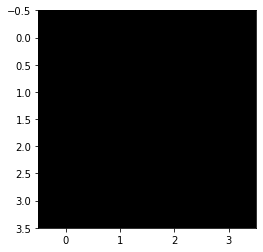

In [1533]:
plt.imshow(inputs[:, :, 0], cmap='gray')

In [1418]:
inputs[0, 0, 0], padded[0, 0, 0]

(tensor(0.), tensor(1.))

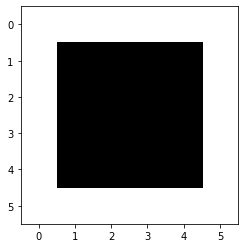

In [1538]:
plt.imshow(padded[:, :, 0], cmap='gray')

In [1327]:
tensor

tensor([[[-1.4285, -0.0609,  1.3419,  0.6077,  1.0035],
         [-0.1598, -0.4895, -0.9102, -0.1358, -0.7100],
         [-1.2829, -0.5258, -0.4707,  0.7018,  0.0496],
         [-0.3021,  0.3924,  1.0898,  0.3704, -0.3465]],

        [[-0.8483,  0.2492, -0.5745, -0.3095, -0.4304],
         [-0.6334,  0.1566,  0.1613,  0.2181,  0.1153],
         [ 0.9662, -1.1887,  0.5499,  1.1544, -0.8507],
         [ 0.1411, -0.3902,  0.7077, -0.1500, -0.2071]],

        [[ 2.0507, -0.1715,  1.2912, -1.1751,  0.2292],
         [-0.8326,  0.2016, -0.3831,  0.2077, -2.2853],
         [ 0.2818, -0.9513, -1.9701, -1.4131,  0.6352],
         [-0.1128,  1.6543, -0.5823,  2.1735, -1.5952]],

        [[ 0.0175,  1.8170,  1.2905, -0.7178, -0.1134],
         [-0.1278, -0.2494,  1.0481, -0.2710,  1.5837],
         [-1.8018, -0.2018,  0.2434, -0.4594, -0.4067],
         [-0.1383,  1.1459, -0.2763, -1.0047,  0.1404]]])

In [1335]:
np.lib.stride_tricks.sliding_window_view(tensor, window_shape=(3, 3, 5))

array([[[[[[-1.4284819 , -0.06087883,  1.3418908 ,  0.6077122 ,
             1.0034963 ],
           [-0.15977323, -0.48948568, -0.9102187 , -0.13579573,
            -0.7099611 ],
           [-1.2829376 , -0.52575946, -0.47065517,  0.7018234 ,
             0.04963254]],

          [[-0.84832764,  0.2492027 , -0.5744821 , -0.30946168,
            -0.43039316],
           [-0.63342315,  0.15661427,  0.16131184,  0.21813844,
             0.11531709],
           [ 0.96619105, -1.1887044 ,  0.5498645 ,  1.1544344 ,
            -0.8506559 ]],

          [[ 2.0507324 , -0.17147906,  1.2911607 , -1.1751359 ,
             0.22916788],
           [-0.83263427,  0.20156369, -0.3830653 ,  0.20767632,
            -2.285276  ],
           [ 0.2817595 , -0.95129776, -1.970122  , -1.413073  ,
             0.63517994]]]],



        [[[[-0.15977323, -0.48948568, -0.9102187 , -0.13579573,
            -0.7099611 ],
           [-1.2829376 , -0.52575946, -0.47065517,  0.7018234 ,
             0.04963254],


In [1539]:
A

array([[[553, 471, 232, ..., 575, 209, 711],
        [346, 373, 221, ..., 527, 690, 455],
        [353, 393, 803, ..., 995,  14, 942],
        ...,
        [752, 275, 433, ..., 367, 202,  96],
        [190, 546, 359, ..., 516, 426, 985],
        [527, 748, 257, ..., 171, 422, 960]],

       [[ 32, 522, 236, ..., 987, 372, 485],
        [279, 892, 300, ..., 218, 913, 972],
        [585, 358, 272, ...,  96, 878, 155],
        ...,
        [685, 294, 838, ..., 551, 233, 241],
        [271, 100, 173, ..., 239, 650, 986],
        [197, 429, 597, ..., 748, 353, 885]],

       [[531, 793, 253, ..., 482, 821,  59],
        [907, 484, 492, ..., 980, 556, 143],
        [127, 748, 668, ..., 282, 696, 773],
        ...,
        [563, 715, 378, ...,  23,  35, 277],
        [289, 926,  65, ..., 423, 687,  59],
        [919, 713, 891, ..., 944, 876, 840]],

       ...,

       [[582, 807, 390, ..., 807, 115, 906],
        [215, 437, 548, ..., 301,  51, 468],
        [490, 184,  99, ..., 444, 435, 463

In [1557]:
5 // 2

2

In [1558]:
padding = K // 2

In [1561]:
np.pad(A, pad_width=((padding, padding), (padding, padding), (0, 0)))

array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [553, 471, 232, ..., 575, 209, 711],
        [346, 373, 221, ..., 527, 690, 455],
        ...,
        [190, 546, 359, ..., 516, 426, 985],
        [527, 748, 257, ..., 171, 422, 960],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [ 32, 522, 236, ..., 987, 372, 485],
        [279, 892, 300, ..., 218, 913, 972],
        ...,
        [271, 100, 173, ..., 239, 650, 986],
        [197, 429, 597, ..., 748, 353, 885],
        [  0,   0,   0, ...,   0,   0,   0]],

       ...,

       [[  0,   0,   0, ...,   0,   0,   0],
        [693,  18,  44, ..., 925, 488, 174],
        [354,  17,  59, ..., 639, 402, 669

In [1355]:
(np.corrcoef(A[0, 0], A[0, 1])[0, 1] + np.corrcoef(A[0, 0], A[1, 0])[0, 1]  + np.corrcoef(A[0, 0], A[1, 1])[0, 1]) / 3

-0.12842313862925858

### Slow solution

In [1366]:
def average_corr(curr_trace, K, curr_i, curr_j):
    K_x, K_y = K, K
    
    if curr_i == 0 or curr_i == A.shape[0] - 1:
        K_y = K - 1
    
    if curr_j == 0 or curr_j == A.shape[1] - 1:
        K_x = K - 1
        
    sum_corr = 0   
    for i in range(0, K_x):
        for j in range(0, K_y):
            if i == curr_i and j == curr_j:
                continue
            sum_corr += np.corrcoef(curr_trace, A[i, j])[0, 1]
            
    return sum_corr / (K_x * K_y - 1)

def window_correlation(output, K, A):
    X = A.shape[0]
    Y = A.shape[1]
    for i in range(X):
        for j in range(Y):
            output[i, j] = average_corr(A[i, j], K, i, j)
    
    return output 

In [1367]:
output = np.zeros((A.shape[0], A.shape[1]))
K = 3

In [1369]:
%%time
window_correlation(output, K, A)

CPU times: user 9min 46s, sys: 444 ms, total: 9min 47s
Wall time: 9min 47s


array([[ 0.0518255 ,  0.08760979, -0.06791963, ...,  0.09609335,
        -0.17483017,  0.00901073],
       [ 0.02779879,  0.05922458, -0.11409826, ..., -0.08141005,
         0.00804854,  0.04493715],
       [-0.00255456,  0.03323767, -0.05320871, ...,  0.07310235,
         0.04695439,  0.05070347],
       ...,
       [-0.03027327,  0.05190031, -0.05111089, ...,  0.02531429,
         0.05766073,  0.08698168],
       [-0.00806217,  0.06500851,  0.01317456, ...,  0.01718193,
         0.04618331, -0.14563017],
       [-0.02856214, -0.06002213,  0.03634247, ..., -0.01620137,
        -0.01014953,  0.09193589]])

In [1375]:
A

array([[[553, 471, 232, ..., 575, 209, 711],
        [346, 373, 221, ..., 527, 690, 455],
        [353, 393, 803, ..., 995,  14, 942],
        ...,
        [752, 275, 433, ..., 367, 202,  96],
        [190, 546, 359, ..., 516, 426, 985],
        [527, 748, 257, ..., 171, 422, 960]],

       [[ 32, 522, 236, ..., 987, 372, 485],
        [279, 892, 300, ..., 218, 913, 972],
        [585, 358, 272, ...,  96, 878, 155],
        ...,
        [685, 294, 838, ..., 551, 233, 241],
        [271, 100, 173, ..., 239, 650, 986],
        [197, 429, 597, ..., 748, 353, 885]],

       [[531, 793, 253, ..., 482, 821,  59],
        [907, 484, 492, ..., 980, 556, 143],
        [127, 748, 668, ..., 282, 696, 773],
        ...,
        [563, 715, 378, ...,  23,  35, 277],
        [289, 926,  65, ..., 423, 687,  59],
        [919, 713, 891, ..., 944, 876, 840]],

       ...,

       [[582, 807, 390, ..., 807, 115, 906],
        [215, 437, 548, ..., 301,  51, 468],
        [490, 184,  99, ..., 444, 435, 463

In [1387]:
pad_correlation_matrix = np.pad(A, ((1, 1)), 'constant', constant_values=(0, 0))
pad_correlation_matrix

array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0, 553, 471, ..., 209, 711,   0],
        [  0, 346, 373, ..., 690, 455,   0],
        ...,
        [  0, 190, 546, ..., 426, 985,   0],
        [  0, 527, 748, ..., 422, 960,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,  32, 522, ..., 372, 485,   0],
        [  0, 279, 892, ..., 913, 972,   0],
        ...,
        [  0, 271, 100, ..., 650, 986,   0],
        [  0, 197, 429, ..., 353, 885,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       ...,

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0, 693,  18, ..., 488, 174,   0],
        [  0, 354,  17, ..., 402, 669,   0

In [329]:
x = np.array([3, 5, 7, 9, 11, 13])
y = np.array([4.55, 13.9, 30.3, 55.3, 104, 184])

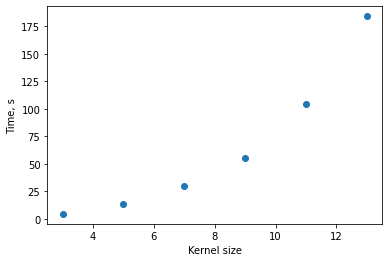

In [333]:
plt.scatter(x, y)
plt.xlabel('Kernel size')
plt.ylabel('Time, s')
plt.show()